## Uçak Mühendisliği Optimizasyonu Veri Bilimcileri İçin

### 01_Pareto_Faydalı Yük-Menzil Optimizasyonu

Bu not defteri, **"Uçak Mühendisliği Optimizasyonu Veri Bilimcileri İçin"** adlı daha büyük proje serisinin ilk not defteridir. Proje, Uçak Mühendisliği, Veri Bilimi, Optimizasyon ve Karar Zekası'nın kesişim noktasına odaklanmaktadır.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import ConvexHull
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Matplotlib settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5

sns.set_style("whitegrid")

# 1. Giriş

Bu bölümde optimizasyon kavramını, tahmin ile arasındaki farkı, havacılık mühendisliğindeki önemini ve faydalı yük-menzil problemlerinin çok amaçlı optimizasyon için neden uygun olduğunu kısaca açıklayacağız.

## Optimizasyon Nedir?

Optimizasyon, belirli bir amaç fonksiyonunu (örneğin, maliyeti minimize etmek veya performansı maksimize etmek) optimize eden bir dizi girdi parametresini bulma sürecidir. Kısıtlamalar dahilinde en iyi çözümü bulmakla ilgilenir.

## Tahmin ve Optimizasyon Arasındaki Fark

*   **Tahmin (Prediction)**, gelecekte ne olacağını anlamak için geçmiş verileri kullanır (örneğin, bir uçağın ne kadar menzil gideceğini tahmin etmek). Odağı, bilinmeyen bir değeri doğru bir şekilde öngörmektir.
*   **Optimizasyon (Optimization)** ise, belirli bir hedefe ulaşmak için ne yapılması gerektiğiyle ilgilenir (örneğin, belirli bir menzil hedefine ulaşmak için bir uçağa ne kadar yakıt yüklenmesi gerektiğini belirlemek). Odağı, en iyi kararları almaktır.

Basitçe söylemek gerekirse, tahmin 'ne' olacağını söylerken, optimizasyon 'ne yapmalı' sorusunu yanıtlar.

## Havacılık Mühendisliğinde Optimizasyonun Önemi

Havacılık mühendisliğinde optimizasyon kritik öneme sahiptir çünkü uçaklar, çok sayıda çelişkili tasarım ve operasyonel kısıtlama altında en uygun performansı sağlamak üzere tasarlanır ve işletilir. Örnekler arasında şunlar yer alır:

*   **Tasarım Optimizasyonu**: Minimum yakıt tüketimiyle maksimum menzil veya faydalı yük kapasitesi.
*   **Operasyonel Optimizasyon**: Uçuş rotalarının optimize edilmesi, yakıt stratejileri ve bakım planlaması.
*   **Maliyet Optimizasyonu**: Üretim maliyetlerinin düşürülmesi ve işletme giderlerinin azaltılması.

## Faydalı Yük-Menzil Problemleri Neden Çok Amaçlı Optimizasyon İçin Uygundur?

Bir uçağın faydalı yükü (taşınan ağırlık, yolcular veya kargo) ile menzili (kat edebileceği mesafe) genellikle birbiriyle çelişen hedeflerdir. Birini artırmak genellikle diğerini azaltır:

*   Daha fazla faydalı yük taşımak için, genellikle daha fazla yakıt gerekir veya daha az yakıt taşınarak menzil kısaltılır.
*   Daha uzun menzil için, genellikle daha fazla yakıt taşınması gerekir, bu da faydalı yük kapasitesini azaltır.

Bu doğal çatışma, faydalı yük-menzil problemlerini çok amaçlı optimizasyon için mükemmel adaylar haline getirir. Amaç, her iki hedefin de eş zamanlı olarak optimize edildiği bir dizi 'en iyi' çözüm (Pareto Çözümleri) bulmaktır. Bu çözümler, mühendislerin belirli operasyonel gereksinimlere göre bilinçli kararlar almasına olanak tanır.

### Uçak Mühendisi → Veri Bilimcisi → Optimizasyon Mühendisi

Bu dönüşüm, modern mühendislik yaklaşımlarının temelini oluşturur. Geleneksel uçak mühendisi, uçuş fiziği ve aerodinamik prensiplerine odaklanırken, veri bilimcisi büyük veri kümelerinden içgörüler çıkarmak için istatistiksel ve makine öğrenimi tekniklerini kullanır. Optimizasyon mühendisi ise, bu içgörüleri kullanarak tasarım ve operasyonel kararları iyileştirmek için matematiksel modeller ve algoritmalar geliştirir. Bu not defterinde, bu üç disiplinin nasıl bir araya gelerek havacılık problemlerine entegre çözümler sunabileceğini keşfedeceğiz.

# 2. Problem Tanımı

Bu bölümde, faydalı yük-menzil optimizasyon problemimizi incelemek için basitleştirilmiş bir turboprop uçak modelini tanımlayacağız. Gerçekçi varsayımlar belirleyecek, karar değişkenlerini, hedefleri ve kısıtlamaları net bir şekilde tanımlayacak ve optimizasyon problemini matematiksel olarak formüle edeceğiz.

## Basitleştirilmiş Turboprop Uçak Modeli Varsayımları

Optimizasyon problemimiz için aşağıdaki gerçekçi varsayımları kullanacağız:

*   **Maksimum Kalkış Ağırlığı (MTOW - Maximum Take-Off Weight)**: Bir uçağın güvenli bir şekilde kalkabileceği maksimum ağırlık.
*   **Boş İşletme Ağırlığı (OEW - Operating Empty Weight)**: Mürettebat, sıvılar ve donanım dahil olmak üzere uçağın operasyonel ağırlığı, ancak yakıt ve faydalı yük hariç.
*   **Maksimum Faydalı Yük (Maximum Payload)**: Uçağın taşıyabileceği maksimum kargo veya yolcu ağırlığı.
*   **Yakıt Kapasitesi (Fuel Capacity)**: Uçağın depolayabileceği maksimum yakıt ağırlığı.
*   **Seyir Hızı (Cruise Speed)**: Uçağın seyir irtifasında sürdürdüğü tipik hız.
*   **Özgül Yakıt Tüketimi (Specific Fuel Consumption - SFC)**: Bir birim itme kuvveti veya güç üretmek için birim zamanda yakıt tüketimi. Bu, Breguet menzil denklemi için kullanılacaktır.

### Model Parametreleri:

*   `max_takeoff_weight_kg`: 6000 kg
*   `operating_empty_weight_kg`: 3500 kg
*   `max_payload_kg`: 2000 kg
*   `max_fuel_capacity_kg`: 1500 kg
*   `cruise_speed_kph`: 450 km/s (seyir hızı)
*   `sfc_kg_per_hr_per_kn`: 0.00008 kg/saat/kN (özgül yakıt tüketimi, kurgusal bir değer)

In [23]:
# Define model parameters (metric units)
MAX_TAKEOFF_WEIGHT_KG: float = 6000.0  # kg
OPERATING_EMPTY_WEIGHT_KG: float = 3500.0  # kg
MAX_PAYLOAD_KG: float = 2000.0  # kg
MAX_FUEL_CAPACITY_KG: float = 1500.0  # kg
CRUISE_SPEED_KPH: float = 450.0  # km/hr
# Specific Fuel Consumption (SFC) - these units are fictional and simplified.
# Real SFC is usually fuel flow rate per unit thrust (e.g., kg/N/s)
# For this model, we use a fictional ratio to simplify range calculation.
# For example, fuel consumption proportional to speed (km/h) and thrust (N) as kg/hr/kN.
SFC_KG_PER_HR_PER_KN: float = 0.00008 # kg / hr / kN (Fictional SFC value)

# Estimate aircraft thrust in a simplified manner (kN)
# In this simple model, we assume a constant thrust.
# In more complex models, thrust varies with speed, altitude, etc.
CRUISE_THRUST_KN: float = 15.0 # kN

## Karar Değişkenleri

Bu optimizasyon probleminde manipüle edeceğimiz veya seçeceğimiz ana değişkenler şunlardır:

*   **Faydalı Yük (Payload)**: Uçağın taşıdığı yolcu veya kargo ağırlığı (kg).
*   **Yakıt Ağırlığı (Fuel Weight)**: Uçağın kalkışta taşıdığı yakıt miktarı (kg).

## Hedefler (Amaç Fonksiyonları)

Çözmeye çalıştığımız iki ana hedefimiz var:

*   **Faydalı Yükü Maksimize Et (Maximize Payload)**: Taşınan kargo veya yolcu miktarını en üst düzeye çıkarmak.
*   **Menzili Maksimize Et (Maximize Range)**: Uçağın kat edebileceği mesafeyi en üst düzeye çıkarmak.

Bu hedefler genellikle birbiriyle çelişir, bu da çok amaçlı optimizasyonu gerekli kılar.

## Kısıtlamalar

Herhangi bir pratik tasarımda veya operasyonda olduğu gibi, modelimizi sınırlayan birkaç kısıtlamamız var:

*   **Maksimum Kalkış Ağırlığı (MTOW)**: Uçağın toplam ağırlığı MTOW'u aşamaz.
    *   `OEW + Payload + Fuel Weight <= MTOW`
*   **Yakıt Kapasitesi (Fuel Capacity)**: Taşınan yakıt miktarı uçağın maksimum yakıt kapasitesini aşamaz.
    *   `Fuel Weight <= Max Fuel Capacity`
*   **Faydalı Yük Limiti (Payload Limit)**: Taşınan faydalı yük miktarı uçağın maksimum faydalı yük kapasitesini aşamaz.
    *   `Payload <= Max Payload`
*   **Fiziksel Fizibilite**: Faydalı yük ve yakıt ağırlığı negatif olamaz.
    *   `Payload >= 0`
    *   `Fuel Weight >= 0`

## Optimizasyon Probleminin Matematiksel Formülasyonu

Yukarıdaki tanıma dayanarak, çok amaçlı optimizasyon problemimiz şu şekilde formüle edilebilir:

**Maksimize Et (Objectives):**

$f_1(	ext{Payload, Fuel Weight}) = 	ext{Payload}$

$f_2(	ext{Payload, Fuel Weight}) = 	ext{Range}(	ext{Payload, Fuel Weight})$

**Konu Şunlara (Constraints):**

$	ext{OEW} + 	ext{Payload} + 	ext{Fuel Weight} \le 	ext{MTOW}$

$	ext{Fuel Weight} \le 	ext{Max Fuel Capacity}$

$	ext{Payload} \le 	ext{Max Payload}$

$	ext{Payload} \ge 0$

$	ext{Fuel Weight} \ge 0$

Burada, $	ext{Range}(	ext{Payload, Fuel Weight})$ aşağıdaki bölümde geliştireceğimiz bir performans modelinden türetilecektir. Bu matematiksel çerçeve, Pareto optimizasyonu aracılığıyla en iyi tasarım seçeneklerini aramamız için bize bir temel sağlar.

# 3. Performans Modeli Oluşturma

Bu bölümde, turboprop uçağımız için basitleştirilmiş bir performans modeli oluşturacağız. Menzil hesaplaması için **Breguet Menzil Denklemi**'ne ve **yakıt kesri** kavramlarına dayanacağız. Ardından, çeşitli faydalı yük ve yakıt kombinasyonları oluşturarak büyük bir tasarım alanı oluşturacak ve sonuçları bir Pandas DataFrame'inde saklayacağız. Son olarak, bir veri örneğini göstereceğiz ve basit keşif amaçlı çizimler oluşturacağız.

## Breguet Menzil Denklemi

Breguet menzil denklemi, bir uçağın taşıyabileceği teorik menzili, başlangıç ve bitiş ağırlıkları, özgül yakıt tüketimi, seyir hızı ve kaldırma-sürükleme oranı gibi faktörlerle ilişkilendiren klasik bir denklemdir. Turboprop uçaklar için, genellikle itme tabanlı bir form kullanılır:

$R = \frac{V}{c_t} \frac{L}{D} \ln\left(\frac{W_i}{W_f}\right)$

Nerede:

*   $R$ = Menzil (km)
*   $V$ = Seyir Hızı (km/s)
*   $c_t$ = Özgül Yakıt Tüketimi (itme tabanlı, örn. kg/N/saat)
*   $L/D$ = Kaldırma-Sürükleme Oranı (birimsiz)
*   $W_i$ = Başlangıç Ağırlığı (kg)
*   $W_f$ = Bitiş Ağırlığı (kg)

Basitlik için, $L/D$ oranını sabit bir değer olarak kabul edeceğiz ve $c_t$'yi önceki bölümde tanımladığımız SFC ile ilişkilendireceğiz. SFC'miz kg/saat/kN cinsinden olduğu için, itme kuvvetini de dikkate alarak $c_t$ terimini kullanabiliriz.

$c_t \approx \text{SFC} \times \text{Cruise Thrust}$

Bu not defterinde, itme kuvvetini basitleştirilmiş bir şekilde sabit kabul edeceğiz ve $c_t$ terimini tek bir sabit olarak birleştireceğiz.

**Basitleştirilmiş Menzil Denklemi Fonksiyonu:**

In [24]:
def calculate_range(payload_kg: float, fuel_weight_kg: float) -> float:
    """
    Calculates the range of the aircraft based on payload and fuel weight.
    Uses a simplified Breguet-like range equation for turboprop aircraft.

    Args:
        payload_kg: The payload weight in kg.
        fuel_weight_kg: The initial fuel weight in kg.

    Returns:
        The estimated range in km.
    """
    initial_weight_kg = OPERATING_EMPTY_WEIGHT_KG + payload_kg + fuel_weight_kg

    # Check for MTOW constraint before calculating range
    if initial_weight_kg > MAX_TAKEOFF_WEIGHT_KG:
        return 0.0  # Invalid design, effectively zero range

    # Check for fuel capacity constraint
    if fuel_weight_kg > MAX_FUEL_CAPACITY_KG:
        return 0.0  # Invalid design, effectively zero range

    # Check for payload capacity constraint
    if payload_kg > MAX_PAYLOAD_KG:
        return 0.0 # Invalid design, effectively zero range

    # Simplified approach for fuel burn during flight.
    # Assume all fuel_weight_kg is available for cruise and burned.
    # In reality, some fuel is for taxi, takeoff, reserve, etc.
    final_weight_kg = initial_weight_kg - fuel_weight_kg

    # Ensure final_weight is positive to avoid log domain error
    if final_weight_kg <= 0:
        return 0.0

    # Simplified L/D ratio for turboprop
    # A realistic L/D for turboprops can be between 10 to 15
    L_OVER_D_RATIO: float = 12.0

    # Effective specific fuel consumption for range calculation
    # Here, we combine SFC_KG_PER_HR_PER_KN with CRUISE_THRUST_KN
    # to get a conceptual 'effective' ct in kg/hour. This is a highly simplified model.
    effective_ct_kg_per_hr = SFC_KG_PER_HR_PER_KN * CRUISE_THRUST_KN * 1000 # Convert kN to N for a more typical ct interpretation

    # Avoid division by zero if effective_ct is too small
    if effective_ct_kg_per_hr == 0:
        return 0.0

    # Breguet Range Equation
    # R = (V / ct) * (L/D) * ln(Wi / Wf)
    # Where V is in km/hr, ct in kg/hr, L/D is dimensionless.
    # The natural log term needs Wi/Wf to be dimensionless.
    try:
        range_km = (CRUISE_SPEED_KPH / effective_ct_kg_per_hr) * L_OVER_D_RATIO * np.log(initial_weight_kg / final_weight_kg)
    except:
        range_km = 0.0 # Handle cases where log input might be invalid (e.g. Wi < Wf)

    return max(0.0, range_km)


## Geniş Bir Tasarım Alanı Oluşturma ve DataFrame Oluşturma

Şimdi, uçağın faydalı yük ve yakıt ağırlığı için tüm fizibil kombinasyonları temsil eden geniş bir tasarım alanı oluşturacağız. Bu, potansiyel tasarım çözümlerini keşfetmek ve daha sonra Pareto optimum çözümlerini tanımlamak için temel oluşturacaktır.

Faydalı yük ve yakıt ağırlığı için aralıklar tanımlayacak ve her bir kombinasyon için menzili hesaplayacağız. Sonuçları daha kolay analiz ve görselleştirme için bir Pandas DataFrame'inde saklayacağız.

In [25]:
# Define value ranges for the design space
num_points: int = 100 # Number of points for each variable
payload_options_kg: np.ndarray = np.linspace(0, MAX_PAYLOAD_KG, num_points)
fuel_options_kg: np.ndarray = np.linspace(0, MAX_FUEL_CAPACITY_KG, num_points)

# Lists to store design space data
design_data: list[dict[str, float]] = []

# Iterate through all payload and fuel combinations
for payload in payload_options_kg:
    for fuel in fuel_options_kg:
        # Check constraints (calculate_range already includes these, but we can also check directly)
        current_gross_weight = OPERATING_EMPTY_WEIGHT_KG + payload + fuel

        if (
            current_gross_weight <= MAX_TAKEOFF_WEIGHT_KG
            and payload <= MAX_PAYLOAD_KG
            and fuel <= MAX_FUEL_CAPACITY_KG
            and payload >= 0
            and fuel >= 0
        ):
            estimated_range = calculate_range(payload, fuel)
            design_data.append({
                'payload_kg': payload,
                'fuel_weight_kg': fuel,
                'gross_weight_kg': current_gross_weight,
                'estimated_range_km': estimated_range
            })

# Convert data to a DataFrame
df_design_space = pd.DataFrame(design_data)

# Filter out invalid ranges (those returning 0)
df_design_space = df_design_space[df_design_space['estimated_range_km'] > 0].reset_index(drop=True)

print(f"Number of design points generated: {len(df_design_space)}")
print("Sample rows from the design space DataFrame:")
print(df_design_space.head())

Number of design points generated: 8217
Sample rows from the design space DataFrame:
   payload_kg  fuel_weight_kg  gross_weight_kg  estimated_range_km
0         0.0       15.151515      3515.151515           19.438475
1         0.0       30.303030      3530.303030           38.793344
2         0.0       45.454545      3545.454545           58.065322
3         0.0       60.606061      3560.606061           77.255116
4         0.0       75.757576      3575.757576           96.363425


## Keşif Amaçlı Çizimler

Tasarım alanının hızlı bir görselleştirmesini elde etmek için bazı temel çizimler oluşturalım. Bu çizimler, farklı parametreler arasındaki genel ilişkileri ve olası eğilimleri anlamamıza yardımcı olacaktır.

In [26]:
def plot_design_space(df: pd.DataFrame, x_col: str, y_col: str, title: str, xlabel: str, ylabel: str):
    """
    Generates a scatter plot for the design space.

    Args:
        df: DataFrame containing the design space data.
        x_col: Column name for the x-axis.
        y_col: Column name for the y-axis.
        title: Title of the plot.
        xlabel: Label for the x-axis.
        ylabel: Label for the y-axis.
    """
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x=x_col, y=y_col, alpha=0.6, s=10)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Payload vs. Range
plot_design_space(
    df_design_space, 'payload_kg', 'estimated_range_km',
    'Payload vs. Estimated Range', 'Payload (kg)', 'Estimated Range (km)'
)

# Fuel Weight vs. Range
plot_design_space(
    df_design_space, 'fuel_weight_kg', 'estimated_range_km',
    'Fuel Weight vs. Estimated Range', 'Fuel Weight (kg)', 'Estimated Range (km)'
)

# Payload vs. Fuel Weight (colored by range)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_design_space, x='payload_kg', y='fuel_weight_kg',
    hue='estimated_range_km', size='estimated_range_km', sizes=(20, 400), alpha=0.7,
    palette='viridis', legend='full'
)
plt.title('Payload vs. Fuel Weight (Colored by Range)')
plt.xlabel('Payload (kg)')
plt.ylabel('Fuel Weight (kg)')
plt.grid(True)
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# 4. Keşifçi Veri Analizi (EDA)

Bu bölümde, oluşturduğumuz tasarım alanı veri setini daha derinlemesine inceleyeceğiz. Amacımız, faydalı yük, yakıt ve menzil arasındaki temel ilişkileri ve olası değiş tokuşları anlamaktır. Profesyonel çizimler oluşturacak ve mühendislik gözlemlerini sunacağız.

## Faydalı Yük vs. Menzil

Faydalı yükün menzil üzerindeki etkisini inceleyelim. Genellikle, belirli bir yakıt ağırlığı için faydalı yük arttıkça menzil azalır. Bu, toplam kalkış ağırlığı kısıtlamasından kaynaklanır.

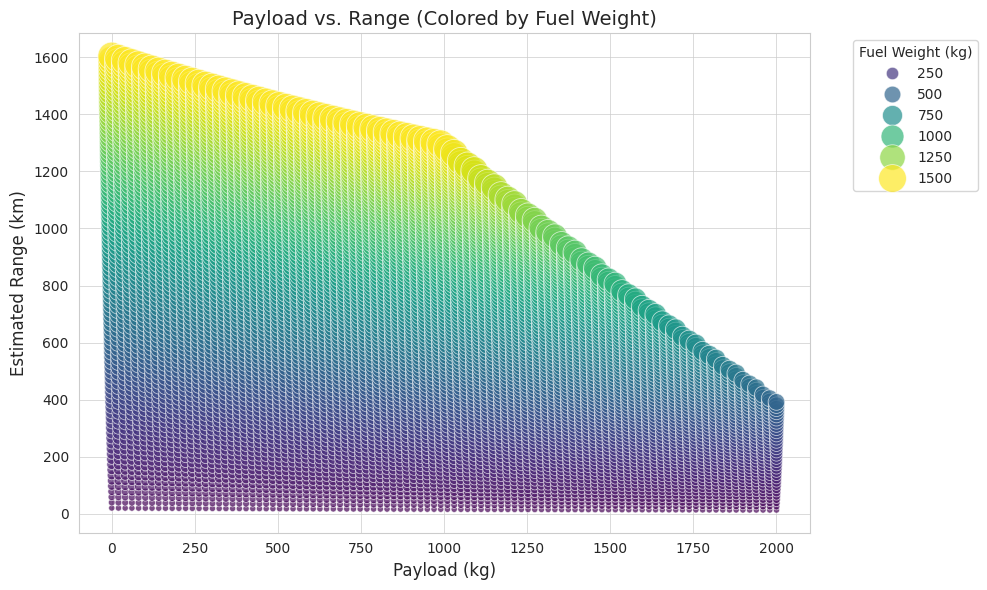

In [27]:
# Payload vs. Range plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_design_space, x='payload_kg', y='estimated_range_km',
    hue='fuel_weight_kg', palette='viridis', size='fuel_weight_kg', sizes=(20, 400), alpha=0.7
)
plt.title('Payload vs. Range (Colored by Fuel Weight)')
plt.xlabel('Payload (kg)')
plt.ylabel('Estimated Range (km)')
plt.legend(title='Fuel Weight (kg)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Engineering Observation:
# Generally, as payload increases, range decreases, especially at fixed fuel levels.
# Higher fuel weights allow for longer ranges even with higher payloads,
# but this is subject to the total takeoff weight constraint.
# This plot shows how different ranges are achieved with a combination of payload and fuel weight.

## Yakıt vs. Menzil

Şimdi yakıt ağırlığının menzil üzerindeki etkisini inceleyelim. Menzil denklemi, daha fazla yakıtın genellikle daha uzun menzile yol açtığını gösterir, ancak bu, faydalı yük ve MTOW kısıtlamaları tarafından sınırlandırılır.

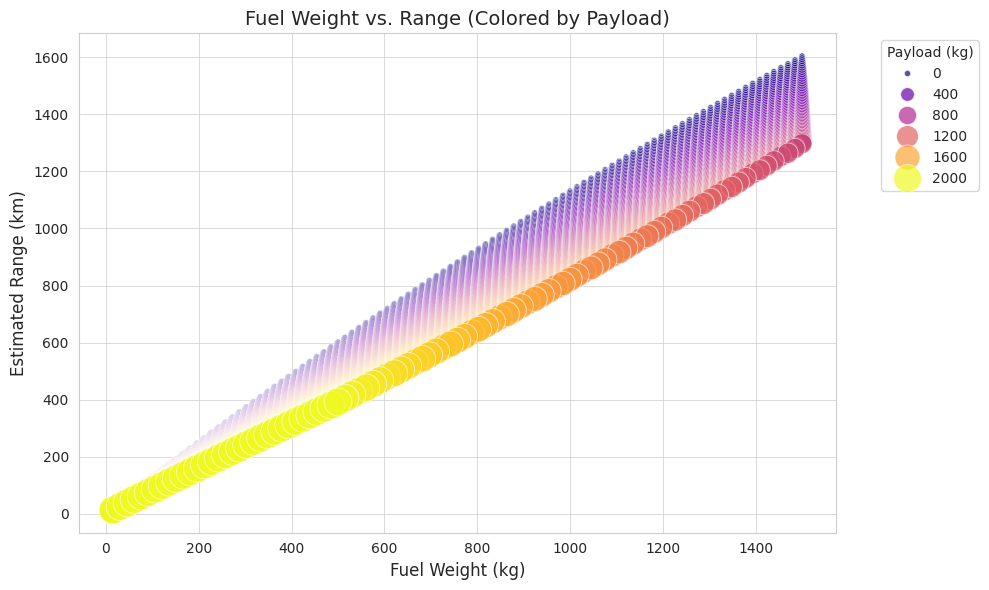

In [28]:
# Fuel vs. Range plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_design_space, x='fuel_weight_kg', y='estimated_range_km',
    hue='payload_kg', palette='plasma', size='payload_kg', sizes=(20, 400), alpha=0.7
)
plt.title('Fuel Weight vs. Range (Colored by Payload)')
plt.xlabel('Fuel Weight (kg)')
plt.ylabel('Estimated Range (km)')
plt.legend(title='Payload (kg)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Engineering Observation:
# More fuel generally means longer range. However,
# as payload increases, the range potential for a given amount of fuel decreases,
# because the MTOW constraint may allow less fuel to be carried.
# This graph clearly shows how the trade-off between fuel and payload affects range.

## Faydalı Yük vs. Yakıt

Bu grafik, iki ana karar değişkenimiz arasındaki ilişkiyi ve bunların brüt ağırlık kısıtlaması içinde nasıl bir değiş tokuş oluşturduğunu görselleştirmek için önemlidir.

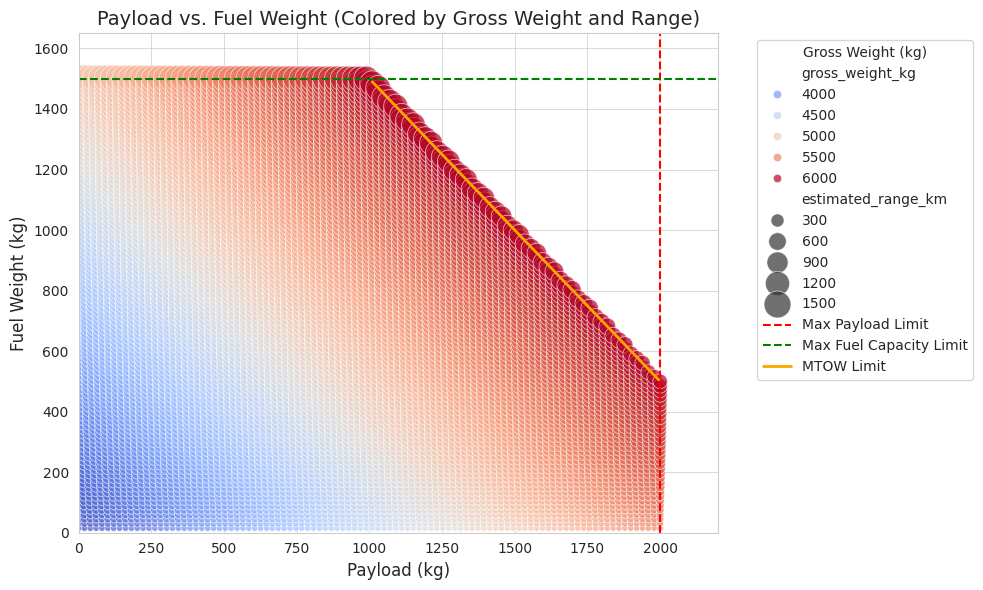

In [29]:
# Payload vs. Fuel Weight plot (gross weight contoured)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_design_space, x='payload_kg', y='fuel_weight_kg',
    hue='gross_weight_kg', palette='coolwarm', size='estimated_range_km', sizes=(20, 400), alpha=0.7
)
plt.axvline(x=MAX_PAYLOAD_KG, color='r', linestyle='--', label='Max Payload Limit')
plt.axhline(y=MAX_FUEL_CAPACITY_KG, color='g', linestyle='--', label='Max Fuel Capacity Limit')

# Add a curved line to show the MTOW constraint
# OEW + Payload + Fuel = MTOW => Fuel = MTOW - OEW - Payload
max_payload_for_mtow = MAX_TAKEOFF_WEIGHT_KG - OPERATING_EMPTY_WEIGHT_KG
mtow_payload_line = np.linspace(0, max_payload_for_mtow, 100)
mtow_fuel_line = MAX_TAKEOFF_WEIGHT_KG - OPERATING_EMPTY_WEIGHT_KG - mtow_payload_line

# Filter so that only positive fuel weights are shown
mtow_fuel_line_filtered = mtow_fuel_line[mtow_fuel_line >= 0]
mtow_payload_line_filtered = mtow_payload_line[:len(mtow_fuel_line_filtered)]

# Limit to MAX_PAYLOAD_KG and MAX_FUEL_CAPACITY_KG only
mtow_payload_line_final = mtow_payload_line_filtered[mtow_payload_line_filtered <= MAX_PAYLOAD_KG]
mtow_fuel_line_final = mtow_fuel_line_filtered[mtow_payload_line_filtered <= MAX_PAYLOAD_KG]

# Also, limit by fuel capacity
mtow_payload_line_final = mtow_payload_line_final[mtow_fuel_line_final <= MAX_FUEL_CAPACITY_KG]
mtow_fuel_line_final = mtow_fuel_line_final[mtow_fuel_line_final <= MAX_FUEL_CAPACITY_KG]

plt.plot(mtow_payload_line_final, mtow_fuel_line_final, color='orange', linestyle='-', linewidth=2, label='MTOW Limit')

plt.title('Payload vs. Fuel Weight (Colored by Gross Weight and Range)')
plt.xlabel('Payload (kg)')
plt.ylabel('Fuel Weight (kg)')
plt.legend(title='Gross Weight (kg)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(0, MAX_PAYLOAD_KG * 1.1) # Show slightly above Max Payload
plt.ylim(0, MAX_FUEL_CAPACITY_KG * 1.1) # Show slightly above Max Fuel
plt.grid(True)
plt.tight_layout()
plt.show()

# Engineering Observation:
# This plot clearly defines the design space, showing the physical trade-off between decision variables (payload and fuel).
# The MTOW constraint creates a direct inverse relationship between payload and fuel: if you increase one,
# you must decrease the other. The different colors and sizes in the plot visualize how these combinations
# lead to different gross weights and thus ranges.
# The red and green dashed lines show the independent payload and fuel capacity limits.
# The orange line shows the impact of the MTOW constraint on the design space.

# 5. Pareto Opti̇mali̇ği̇ne Gi̇ri̇ş

Bu bölümde, çok amaçlı optimizasyonun temel bir kavramı olan Pareto Opti̇mali̇ği̇ni tanıtacağız. Egemen (dominated) ve egemen olmayan (non-dominated) çözümlerin ne olduğunu açıklayacak, basit görsel örnekler sunacak ve havacılık bağlamında sezgisel bir yorum sağlayacağız. Teoriyi mümkün olduğunca kısa tutacağız.

## Egemen (Dominated) ve Egemen Olmayan (Non-Dominated) Çözümler

Çok amaçlı optimizasyonda, genellikle birden fazla (ve genellikle çelişkili) hedefi aynı anda optimize etmeye çalışırız. Bir tasarım çözümü diğerine göre 'daha iyi' olduğunda, bu kavramı tanımlamak için 'egemenlik' terimini kullanırız.

*   **Egemen Çözüm (Dominated Solution)**: Bir çözüm (A), diğer bir çözüm (B) tarafından egemen olarak kabul edilir, eğer:
    *   B, en az bir hedefte A'dan daha iyiyse,
    *   Ve B, diğer tüm hedeflerde A'dan daha kötü değilse.
    
    Basitçe söylemek gerekirse, egemen bir çözüm, tüm hedeflerde en az onun kadar iyi olan ve en az bir hefte ondan kesinlikle daha iyi olan başka bir çözümün var olduğu bir çözümdür.

*   **Egemen Olmayan Çözüm (Non-Dominated Solution)**: Bir çözüm, eğer tasarım alanındaki başka hiçbir çözüm onu egemen kılmıyorsa, egemen olmayan bir çözümdür.

## Pareto Opti̇mali̇ği̇

Egemen olmayan çözümler kümesi, **Pareto Optimal Kümesi** veya **Pareto Cephesi (Pareto Front)** olarak bilinir. Bu cephe üzerindeki çözümler, çok amaçlı bir problem için

In [30]:
def is_pareto_efficient(costs: np.ndarray) -> np.ndarray:
    """
    Find the Pareto-efficient points given a set of costs.
    Assumes minimization for all objectives.
    For maximization, multiply objectives by -1.

    Args:
        costs: A (num_points, num_objectives) array of objective values.

    Returns:
        A boolean array of shape (num_points,) indicating whether each point is Pareto-efficient.
    """
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            # Check if current point is dominated by any other efficient point
            # (c >= costs).all() checks if current point is worse or equal in all objectives
            # (c > costs).any() checks if current point is strictly worse in at least one objective
            is_efficient[is_efficient] = np.any(costs[is_efficient] < c, axis=1) | np.all(costs[is_efficient] == c, axis=1)
            # The above line needs careful correction for true Pareto dominance
            # A simpler, though potentially slower, approach for clarity:
            # A point `i` is Pareto-efficient if no other point `j` dominates it.
            # Point `j` dominates point `i` if `j` is better than `i` in at least one objective
            # AND `j` is not worse than `i` in any other objective.

            # For maximization (our case: Payload, Range), we want to maximize values.
            # Let's convert to minimization by multiplying by -1.
            # So, point j dominates point i if (-obj_j >= -obj_i) for all objectives AND
            # (-obj_j > -obj_i) for at least one objective.
            # Which means (obj_j <= obj_i) for all objectives AND (obj_j < obj_i) for at least one.

            # Redefine is_efficient for maximization problem (assuming larger values are better)
            # We're looking for points that are NOT dominated.
            # A point 'a' dominates 'b' if: (a >= b) in all objectives AND (a > b) in at least one objective.

            # Create a boolean array where True means 'is_dominated'
            dominated_by_others = np.any(np.all(costs >= c, axis=1) & np.any(costs > c, axis=1))
            if dominated_by_others:
                is_efficient[i] = False
    return is_efficient

def find_pareto_front(df: pd.DataFrame, obj_cols: list[str], maximize: bool = True) -> pd.DataFrame:
    """
    Identifies the Pareto front from a DataFrame of solutions.

    Args:
        df: DataFrame containing the solutions.
        obj_cols: List of column names representing the objectives.
        maximize: If True, objectives are maximized. If False, minimized.

    Returns:
        A DataFrame containing only the Pareto-optimal solutions.
    """
    # Extract objective values
    objectives = df[obj_cols].values

    # For maximization, convert to minimization by multiplying by -1
    if maximize:
        objectives = -objectives

    # Initialize an array to keep track of non-dominated points
    is_non_dominated = np.ones(objectives.shape[0], dtype=bool)

    for i in range(objectives.shape[0]):
        for j in range(objectives.shape[0]):
            if i == j:
                continue
            # Check if point j dominates point i (for minimization)
            # Point j dominates i if all objectives of j are <= objectives of i
            # AND at least one objective of j is strictly < objectives of i
            if np.all(objectives[j] <= objectives[i]) and np.any(objectives[j] < objectives[i]):
                is_non_dominated[i] = False
                break

    return df[is_non_dominated].copy().reset_index(drop=True)


## Basit Görsel Örnekler

Şimdi Pareto Optimalite kavramlarını görselleştirmek için basit bir örnek oluşturalım. İki hedefimiz olduğunu varsayalım: `Hedef 1`'i ve `Hedef 2`'yi maksimize etmek.

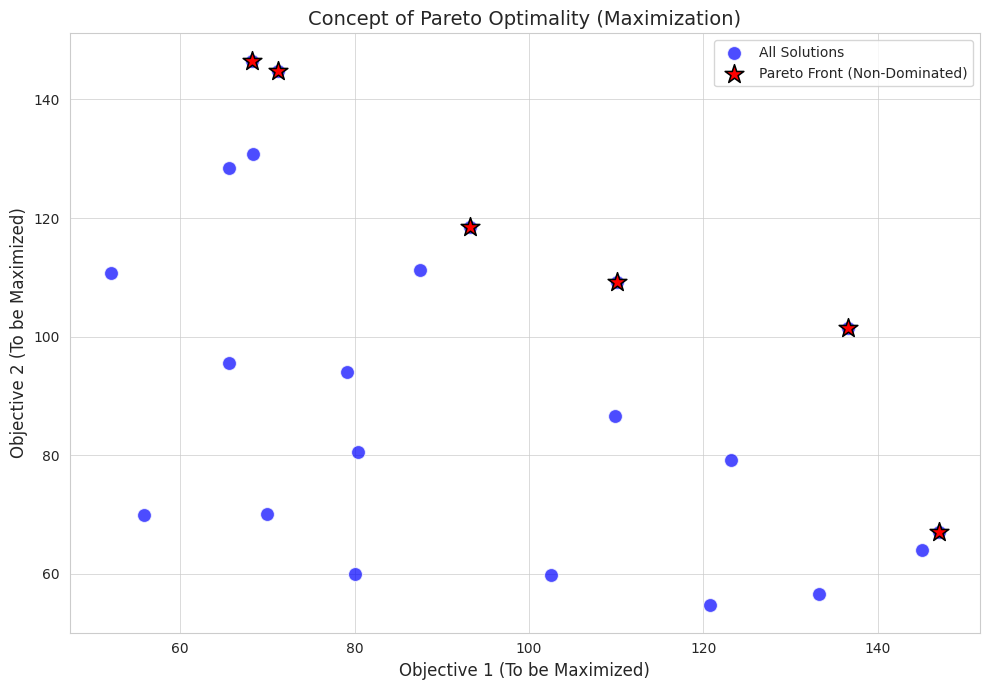

In [31]:
# Generate sample data (maximize two objectives)
np.random.seed(42)
sample_data = pd.DataFrame({
    'id': range(20),
    'Objective1': np.random.rand(20) * 100 + 50, # Between 50-150
    'Objective2': np.random.rand(20) * 100 + 50  # Between 50-150
})

# Intentionally add dominated points
sample_data.loc[20] = {'id': 20, 'Objective1': 70, 'Objective2': 70} # Dominated by most points
sample_data.loc[21] = {'id': 21, 'Objective1': 80, 'Objective2': 60} # Dominated by some points

# Find the Pareto front
pareto_front_sample = find_pareto_front(sample_data, ['Objective1', 'Objective2'], maximize=True)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=sample_data, x='Objective1', y='Objective2', color='blue', label='All Solutions', s=100, alpha=0.7)
sns.scatterplot(data=pareto_front_sample, x='Objective1', y='Objective2', color='red', label='Pareto Front (Non-Dominated)', s=200, marker='*', edgecolor='black')

plt.title('Concept of Pareto Optimality (Maximization)')
plt.xlabel('Objective 1 (To be Maximized)')
plt.ylabel('Objective 2 (To be Maximized)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Engineering Observation:
# Blue points represent all possible design solutions. Red stars form the Pareto front.
# Each solution on the Pareto front is one where it's not possible to improve one objective
# without sacrificing another. For example, if you move right from one of the red stars (improve Objective 1),
# you typically have to move down (worsen Objective 2).
# Points outside the Pareto front (blue) are solutions that can be improved in one or both objectives.

## Sezgisel Bir Havacılık Yorumu

Faydalı yük-menzil optimizasyon problemimize dönecek olursak:

*   **Faydalı Yükü Maksimize Etmek**
*   **Menzili Maksimize Etmek**

Bu iki hedef genellikle birbiriyle çelişir. Daha uzun menzil genellikle daha fazla yakıt gerektirir, bu da uçağın maksimum kalkış ağırlığı kısıtlamasına uyması için daha az faydalı yük taşıması gerektiği anlamına gelir. Tersine, daha fazla faydalı yük taşımak, daha az yakıt anlamına gelebilir ve dolayısıyla menzili azaltabilir.

**Pareto Cephesi'ndeki Bir Uçak Tasarımı:**

Bir uçak, faydalı yük-menzil Pareto cephesinde yer alıyorsa, bu şu anlama gelir:

*   **Egemen Olmayan Tasarım**: Bu uçak yapılandırması (belirli bir faydalı yük ve yakıt kombinasyonu), başka hiçbir yapılandırma tarafından **her iki hedefte de (faydalı yük VE menzil)** aynı anda daha iyi veya en azından eşit değildir.
*   **Değiş Tokuş**: Pareto cephesindeki bir tasarımdan diğerine geçmek, bir hedefte kazanç elde ederken diğerinde mutlaka bir kayıp yaşayacağınız anlamına gelir. Örneğin, faydalı yükü artırmak için menzilden feragat etmeniz gerekebilir veya tam tersi.

Gerçek dünyada, bu, havayolu şirketlerinin veya uçak tasarımcılarının belirli bir görev için en uygun uçağı seçerken karşılaştığı bir durumdur. Kısa menzilli, yüksek kapasiteli bir kargo uçağı farklı bir Pareto noktası üzerinde yer alırken, uzun menzilli, düşük faydalı yüklü bir keşif uçağı başka bir Pareto noktasında yer alabilir. Pareto cephesi, karar vericilere, ödünleşimlerin en iyi olduğu bir dizi optimal seçenek sunar.

# 6. Pareto Cephesi Oluşturma

Bu bölümde, önceki bölümlerde oluşturduğumuz tasarım alanı veri setinden Pareto cephesini oluşturacağız. Hem domine edilmiş hem de Pareto-optimal tasarımları belirleyecek ve bunları görselleştirmelerle açıkça vurgulayacağız. Bu, karar vericilerin en iyi ödünleşimleri gözlemleyebileceği bir dizi çözümün somut bir temsilini sağlayacaktır.

## Pareto Cephesi Arama Algoritması Uygulaması

Önceden tanımladığımız `find_pareto_front` fonksiyonunu kullanarak, `df_design_space` DataFrame'imizdeki faydalı yük ve menzil hedeflerini maksimize eden Pareto optimal çözümleri bulacağız.

In [32]:
# Define objective columns (we are maximizing Payload and Range)
objective_columns: list[str] = ['payload_kg', 'estimated_range_km']

# Find the Pareto front
df_pareto_front = find_pareto_front(df_design_space, objective_columns, maximize=True)

print(f"Total number of design points: {len(df_design_space)}")
print(f"Number of Pareto-optimal points: {len(df_pareto_front)}")

print("\nFirst 5 Pareto-optimal solutions:")
print(df_pareto_front.head())

Total number of design points: 8217
Number of Pareto-optimal points: 100

First 5 Pareto-optimal solutions:
   payload_kg  fuel_weight_kg  gross_weight_kg  estimated_range_km
0    0.000000          1500.0      5000.000000         1605.037248
1   20.202020          1500.0      5020.202020         1597.283082
2   40.404040          1500.0      5040.404040         1589.604252
3   60.606061          1500.0      5060.606061         1581.999655
4   80.808081          1500.0      5080.808081         1574.468209


## Tüm Tasarımların ve Pareto Cephesinin Görselleştirilmesi

Şimdi, tüm tasarım noktalarını, Pareto cephesi üzerindeki optimal çözümleri açıkça vurgulayarak görselleştirelim. Bu grafik, egemen ve egemen olmayan çözümler arasındaki farkı sezgisel olarak anlamamızı sağlayacaktır.

**Grafik Açıklaması:**

*   **Mavi Noktalar**: Olası tüm fizibil tasarım çözümlerini temsil eder.
*   **Kırmızı Yıldızlar**: Pareto cephesini oluşturan egemen olmayan çözümleri temsil eder. Bunlar, bir hedeften ödün vermeden diğer hedefin iyileştirilemeyeceği en iyi değiş tokuş noktalarıdır.

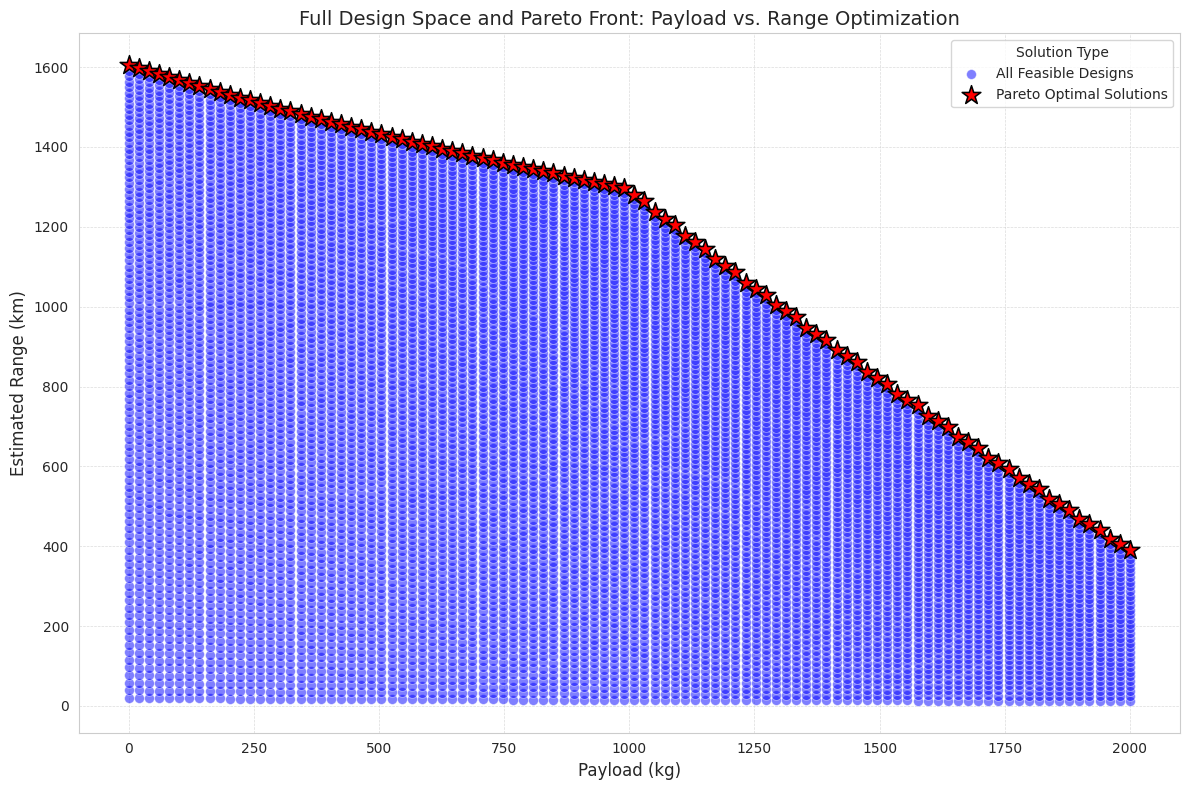

In [33]:
plt.figure(figsize=(12, 8))

# Plot all design points
sns.scatterplot(
    data=df_design_space, x='payload_kg', y='estimated_range_km',
    color='blue', alpha=0.5, s=50, label='All Feasible Designs'
)

# Plot points on the Pareto front
sns.scatterplot(
    data=df_pareto_front, x='payload_kg', y='estimated_range_km',
    color='red', marker='*', s=200, edgecolor='black', zorder=5,
    label='Pareto Optimal Solutions'
)

plt.title('Full Design Space and Pareto Front: Payload vs. Range Optimization')
plt.xlabel('Payload (kg)')
plt.ylabel('Estimated Range (km)')
plt.legend(title='Solution Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Engineering Observation:
# The graph clearly shows a trade-off between payload and range.
# The Pareto front, represented by red stars, defines the best trade-off solutions.
# Each of these solutions means that to move to another solution, one objective must be sacrificed.
# For example, to get more range, payload must be sacrificed, and vice versa.
# The blue points below or to the left of the Pareto front are designs that are always dominated by one of the red stars
# (i.e., there is a solution that is better or equal in both payload and range, and strictly better in at least one).
# Therefore, these dominated solutions are generally less desirable.

# 7. Çok Amaçlı Optimizasyon

Bu bölümde, çok amaçlı optimizasyon iş akışını uygulayacak, objektif alanı ve tasarım alanını görselleştirecek ve çelişen hedefler ile bunların mühendislik yorumları hakkında tartışacağız.

## Objektif Alan ve Tasarım Alanı

**Tasarım Alanı**: Optimizasyon problemimizin karar değişkenlerinin (örneğin, faydalı yük ve yakıt ağırlığı) değerlerini temsil ettiği alandır.

**Objektif Alan**: Optimizasyon problemimizin hedeflerinin (örneğin, menzil ve faydalı yük) değerlerini temsil ettiği alandır.

İdeal olarak, tasarım alanında yapılan değişikliklerin objektif alanında nasıl sonuçlandığını görmek isteriz.

### Tasarım Alanını Görselleştirme (Karar Değişkenleri)

Faydalı yük ve yakıt ağırlığı arasındaki ilişkiyi gösteren tasarım alanını tekrar ziyaret edelim, ancak şimdi Pareto optimal noktaları vurgulayarak.

In [34]:
plt.figure(figsize=(12, 8))

# Plot all design points
sns.scatterplot(
    data=df_design_space, x='payload_kg', y='fuel_weight_kg',
    hue='estimated_range_km', palette='viridis', size='estimated_range_km', sizes=(20, 400), alpha=0.6,
    legend='full' # legend='full' is needed when hue is used to display the legend
)

# Plot design space coordinates of points on the Pareto front
sns.scatterplot(
    data=df_pareto_front, x='payload_kg', y='fuel_weight_kg',
    color='red', marker='X', s=250, edgecolor='black', zorder=5,
    label='Pareto Optimal Designs (Decision Variables)'
)

plt.title('Design Space: Payload vs. Fuel Weight (Colored by Range)')
plt.xlabel('Payload (kg)')
plt.ylabel('Fuel Weight (kg)')
plt.legend(title='Range (km)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Engineering Observation:
# This graph helps engineers understand how a specific combination of payload and fuel weight (decision variables)
# translates into range and payload objectives that make an aircraft Pareto optimal.
# The red 'X' marks show the location of Pareto optimal solutions in the design space.
# This helps identify which decisions in the design space (choice of fuel and payload)
# lead to optimal performance in the objective space (range and payload).

Output hidden; open in https://colab.research.google.com to view.

### Objektif Alanı Görselleştirme (Hedefler)

Önceden yaptığımız gibi, faydalı yük ve menzil hedeflerini gösteren objektif alanını tekrar çizelim, ancak şimdi Pareto cephesinin rolünü vurgulayarak. Bu, Pareto cephesinin 'gerçek' konumunu, yani hedeflerin değerlerinin kendilerini gösterir.

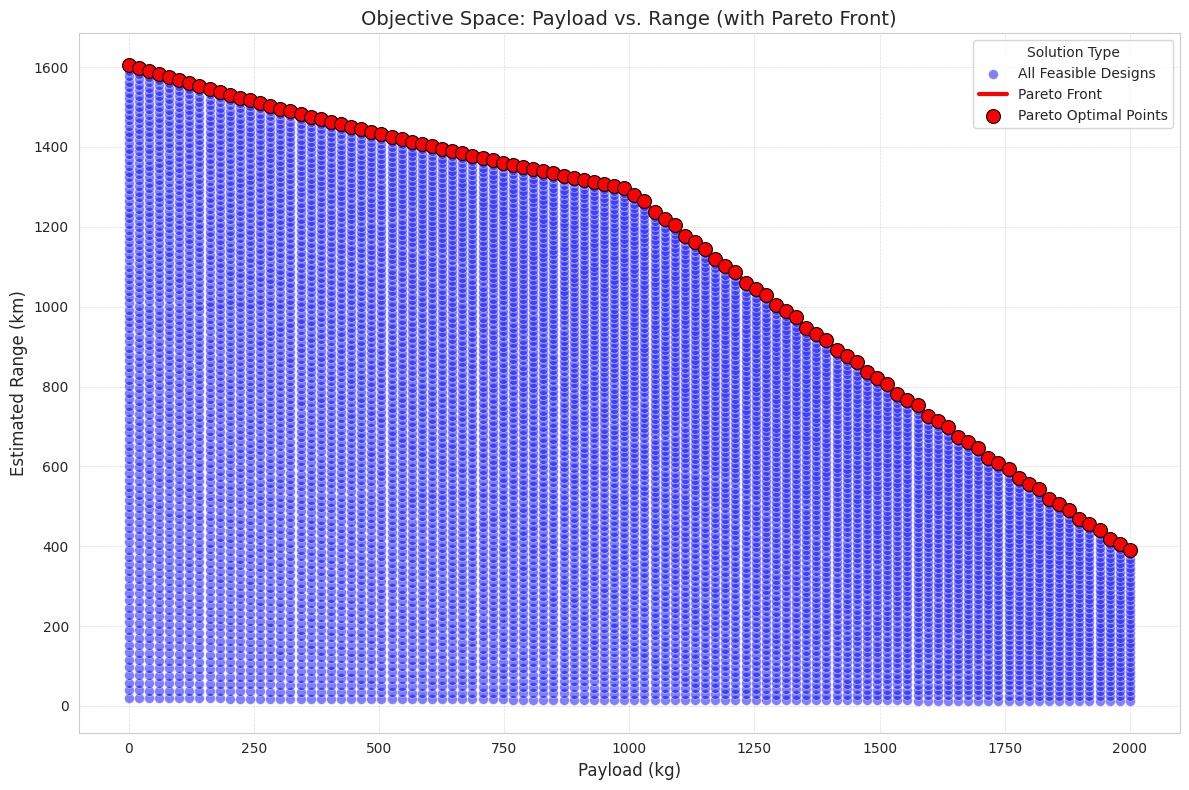

In [35]:
plt.figure(figsize=(12, 8))

# Plot all design points
sns.scatterplot(
    data=df_design_space, x='payload_kg', y='estimated_range_km',
    color='blue', alpha=0.5, s=50, label='All Feasible Designs'
)

# Plot points on the Pareto front
sns.lineplot(
    data=df_pareto_front.sort_values(by='payload_kg'), x='payload_kg', y='estimated_range_km',
    color='red', linewidth=3, label='Pareto Front'
)
sns.scatterplot(
    data=df_pareto_front, x='payload_kg', y='estimated_range_km',
    color='red', marker='o', s=100, edgecolor='black', zorder=5,
    label='Pareto Optimal Points'
)

plt.title('Objective Space: Payload vs. Range (with Pareto Front)')
plt.xlabel('Payload (kg)')
plt.ylabel('Estimated Range (km)')
plt.legend(title='Solution Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Engineering Observation:
# This objective space visualization clearly shows the inherent conflict
# between maximizing payload and maximizing range. The Pareto front (red line and points)
# represents the curve of equilibrium points where both objectives are optimally optimized simultaneously.
# Decision-makers can choose the most suitable trade-off point on this curve
# for a specific task or operational requirement.

## Çelişen Hedefler ve Mühendislik Yorumları

Yukarıdaki grafikler, faydalı yükü artırmanın genellikle menzili azaltma pahasına geldiğini ve bunun tersini göstermektedir. Bu, havacılık tasarımında ve operasyonunda karşılaşılan temel bir değiş tokuştur.

**Mühendislik Yorumları:**

*   **Çelişki (Trade-off)**: Faydalı yük ve menzil doğrudan çelişen hedeflerdir. Birini artırmak genellikle diğerini azaltır. Bu, uçağın toplam kalkış ağırlığı, yakıt kapasitesi ve aerodinamik performansı gibi fiziksel kısıtlamalar nedeniyle böyledir.
*   **Karar Vericiler İçin Seçenekler**: Pareto cephesi, herhangi bir tasarımın diğer bir tasarımdan daha iyi olmadığı bir dizi 'optimal' çözümü sunar. Bu, bir havayolunun belirli bir rota veya misyon için yüksek faydalı yük (kısa menzil) mi yoksa uzun menzil (düşük faydalı yük) mi istediğine karar vermesine olanak tanır.
*   **Denge Çözümleri**: Pareto cephesi boyunca, daha az aşırı olan ve hem faydalı yük hem de menzil arasında makul bir denge sağlayan çözümler bulunabilir. Bu 'dengeli' çözümler, tipik operasyonlar için genellikle pratik seçimlerdir.
*   **Tasarım Sınırları**: Pareto cephesinin uç noktaları, maksimum faydalı yük (minimum menzille) veya maksimum menzil (minimum faydalı yükle) gibi performansın teorik sınırlarını temsil eder. Bu noktalar, bir uçağın yeteneklerinin sınırlarını anlamak için önemlidir.

Çok amaçlı optimizasyonun amacı, tek bir 'en iyi' çözüm bulmak değil, karar vericilerin bilinçli seçimler yapabileceği bir dizi uygun çözüm sunmaktır. Pareto cephesi, bu seçenekleri net ve yapılandırılmış bir şekilde sunar.

# 8. Karar Analizi

Bu bölümde, Pareto cephesini kullanarak farklı mühendislik ve operasyonel senaryolar için karar analizi yapacağız. Amaç, belirli hedeflere (örneğin, maksimum faydalı yük veya maksimum menzil) dayalı olarak uygun tasarımları otomatik olarak belirlemek ve bunların avantajları ile dezavantajlarını tartışmaktır.

## Karar Senaryoları Oluşturma

Uçak tasarımında ve operasyonunda karşılaşılabilecek dört tipik karar senaryosunu inceleyeceğiz:

*   **Senaryo A: Maksimum Faydalı Yük**: En yüksek faydalı yük kapasitesine sahip tasarımı önceliklendirir, menzil ikincil önceliktir.
*   **Senaryo B: Maksimum Menzil**: En uzun menzile sahip tasarımı önceliklendirir, faydalı yük ikincil önceliktir.
*   **Senaryo C: Dengeli Çözüm**: Faydalı yük ve menzil arasında iyi bir denge sağlayan bir tasarımı hedefler.
*   **Senaryo D: Operasyonel Uzlaşma**: Belirli operasyonel kısıtlamaları (örneğin, minimum faydalı yük ve menzil gereksinimleri) karşılayan bir çözümü bulur.

Bu senaryolar için Pareto cephesinden uygun aday tasarımları otomatik olarak belirleyeceğiz.

In [36]:
def identify_candidate_designs(df_pareto: pd.DataFrame) -> dict[str, pd.Series]:
    """
    Identifies candidate designs for different decision scenarios from the Pareto front.

    Args:
        df_pareto: DataFrame containing the Pareto-optimal solutions.

    Returns:
        A dictionary where keys are scenario names and values are pandas Series
        representing the chosen design for that scenario.
    """
    candidate_designs: dict[str, pd.Series] = {}

    # Scenario A: Maximum Payload
    # Find the design with the highest payload among Pareto solutions
    scenario_a = df_pareto.loc[df_pareto['payload_kg'].idxmax()]
    candidate_designs['Maximum Payload (Scenario A)'] = scenario_a

    # Scenario B: Maximum Range
    # Find the design with the highest range among Pareto solutions
    scenario_b = df_pareto.loc[df_pareto['estimated_range_km'].idxmax()]
    candidate_designs['Maximum Range (Scenario B)'] = scenario_b

    # Scenario C: Balanced Solution
    # A balanced solution can be subjective. One common approach is to normalize
    # objectives and find the point closest to the ideal (max payload, max range).
    # Or, find the point in the 'middle' of the Pareto front curve.
    # For simplicity, let's find a point that balances both, for example,
    # by minimizing the Euclidean distance to a hypothetical 'ideal' point after normalization.

    normalized_payload = df_pareto['payload_kg'] / df_pareto['payload_kg'].max()
    normalized_range = df_pareto['estimated_range_km'] / df_pareto['estimated_range_km'].max()
    # For a balanced solution, we can look for the point that maximizes the sum of normalized objectives
    # or minimizes the distance to the 'ideal' point (1,1) in the normalized objective space.
    balanced_score = normalized_payload + normalized_range
    scenario_c = df_pareto.loc[balanced_score.idxmax()]
    candidate_designs['Balanced Solution (Scenario C)'] = scenario_c

    # Scenario D: Operational Compromise
    # Example: Minimum required payload of 1000 kg and minimum required range of 800 km.
    min_req_payload = 1000.0
    min_req_range = 800.0

    # Filter Pareto solutions that meet these operational requirements
    operational_candidates = df_pareto[
        (df_pareto['payload_kg'] >= min_req_payload) &
        (df_pareto['estimated_range_km'] >= min_req_range)
    ]

    if not operational_candidates.empty:
        # From these, we might pick the one that is 'most balanced' or highest in one objective.
        # For this example, let's pick the one with the highest payload among those meeting criteria.
        scenario_d = operational_candidates.loc[operational_candidates['payload_kg'].idxmax()]
        candidate_designs['Operational Compromise (Scenario D)'] = scenario_d
    else:
        # If no solution meets the criteria, we can report that.
        candidate_designs['Operational Compromise (Scenario D)'] = pd.Series({
            'payload_kg': np.nan, 'fuel_weight_kg': np.nan,
            'gross_weight_kg': np.nan, 'estimated_range_km': np.nan,
            'Notes': 'No Pareto solution meets the operational criteria (1000kg payload, 800km range).'
        })

    return candidate_designs

candidate_designs = identify_candidate_designs(df_pareto_front)

print("Candidate Designs:")
for name, design in candidate_designs.items():
    print(f"\n--- {name} ---")
    print(design.round(2))

Candidate Designs:

--- Maximum Payload (Scenario A) ---
payload_kg            2000.00
fuel_weight_kg         500.00
gross_weight_kg       6000.00
estimated_range_km     391.55
Name: 99, dtype: float64

--- Maximum Range (Scenario B) ---
payload_kg               0.00
fuel_weight_kg        1500.00
gross_weight_kg       5000.00
estimated_range_km    1605.04
Name: 0, dtype: float64

--- Balanced Solution (Scenario C) ---
payload_kg             989.9
fuel_weight_kg        1500.0
gross_weight_kg       5989.9
estimated_range_km    1297.1
Name: 49, dtype: float64

--- Operational Compromise (Scenario D) ---
payload_kg            1515.15
fuel_weight_kg         984.85
gross_weight_kg       6000.00
estimated_range_km     806.83
Name: 75, dtype: float64


## Tasarım Karşılaştırma Tablosu

Seçilen aday tasarımları daha kolay karşılaştırmak için bir tablo oluşturalım.

In [37]:
df_comparison = pd.DataFrame(candidate_designs).T
# Check 'Notes' column and round other numerical columns
for col in df_comparison.columns:
    if col != 'Notes':
        df_comparison[col] = df_comparison[col].apply(lambda x: round(x, 2) if pd.notna(x) else x)

print("Comparison of Candidate Designs:")
print(df_comparison.to_markdown(numalign="left", stralign="left"))

Comparison of Candidate Designs:
|                                     | payload_kg   | fuel_weight_kg   | gross_weight_kg   | estimated_range_km   |
|:------------------------------------|:-------------|:-----------------|:------------------|:---------------------|
| Maximum Payload (Scenario A)        | 2000         | 500              | 6000              | 391.55               |
| Maximum Range (Scenario B)          | 0            | 1500             | 5000              | 1605.04              |
| Balanced Solution (Scenario C)      | 989.9        | 1500             | 5989.9            | 1297.1               |
| Operational Compromise (Scenario D) | 1515.15      | 984.85           | 6000              | 806.83               |


## Her Bir Tasarımın Avantajları ve Dezavantajları

Şimdi her bir senaryo için belirlenen aday tasarımlarının mühendislik ve operasyonel etkilerini tartışalım.

### Maksimum Faydalı Yük (Scenario A)

*   **Avantajlar**: Maksimum kargo veya yolcu taşıma kapasitesi sağlar, bu da yüksek hacimli nakliye veya yolcu taşımacılığı görevleri için idealdir. Uçağın gelir potansiyelini artırabilir.
*   **Dezavantajlar**: Genellikle önemli ölçüde daha kısa menzile sahiptir, çünkü yakıt yerine faydalı yük önceliklendirilir. Bu, daha sık yakıt ikmali duruşları veya daha kısa rotalar anlamına gelebilir.

### Maksimum Menzil (Scenario B)

*   **Avantajlar**: Uçağın tek bir duruşla en uzun mesafeyi kat etmesini sağlar. Uzun menzilli operasyonlar, keşif görevleri veya yakıt ikmali altyapısının sınırlı olduğu bölgeler için kritiktir.
*   **Dezavantajlar**: En düşük faydalı yük kapasitesine sahip olacaktır. Yakıt ağırlığı, MTOW kısıtlaması nedeniyle faydalı yük ağırlığını kısıtlar. Bu, karlı olmayan bir operasyonel senaryoya yol açabilir eğer faydalı yük de önemliyse.

### Dengeli Çözüm (Scenario C)

*   **Avantajlar**: Hem faydalı yük hem de menzil hedeflerinde makul bir performans sağlar. Çoğu genel amaçlı operasyon için esneklik sunar ve aşırı uçlardaki dezavantajları azaltır.
*   **Dezavantajlar**: Herhangi bir hedefte tek başına 'en iyi' değildir. Özel görev gereksinimleri çok yüksek faydalı yük veya menzil gerektirdiğinde yetersiz kalabilir.

### Operasyonel Uzlaşma (Scenario D)

*   **Avantajlar**: Belirli operasyonel eşik değerlerini (örneğin, belirli bir faydalı yük ve menzil) karşılamak üzere tasarlanmıştır. Bu, gerçek dünya misyon gereksinimleri için uygun bir minimum performans garanti eder.
*   **Dezavantajlar**: Optimum Pareto cephesi üzerinde olmasına rağmen, diğer senaryolara göre daha az 'maksimal' olabilir. Kriterler çok kısıtlayıcıysa, fizibil bir çözüm bulunamayabilir veya çözüm alanı çok dar olabilir.

Bu analiz, mühendislerin ve karar vericilerin belirli operasyonel ihtiyaçlara ve önceliklere göre en uygun uçak tasarımını veya operasyon stratejisini seçerken bilinçli kararlar almasına olanak tanır. Pareto cephesi, bu ödünleşimleri nicel ve görsel bir şekilde sunarak karmaşık karar alma süreçlerini basitleştirir.

# 9. Duyarlılık Analizi

Bu bölümde, temel model parametrelerinin (örneğin, yakıt kapasitesi, faydalı yük limitleri ve özgül yakıt tüketimi) Pareto Cephesini ve genel performansını nasıl etkilediğini inceleyeceğiz. Parametre taramaları gerçekleştirecek, ilgili çizimleri üretecek ve hangi değişkenlerin uçak performansını en çok etkilediğini tartışacağız.

## Yakıt Kapasitesi Duyarlılığı

Uçağın maksimum yakıt kapasitesindeki değişikliklerin menzil ve faydalı yük üzerindeki etkisini inceleyelim. Daha fazla yakıt taşıma kapasitesi, uçağın daha uzun menzillere ulaşmasını sağlayabilir, ancak bu, MTOW kısıtlamasına tabidir.

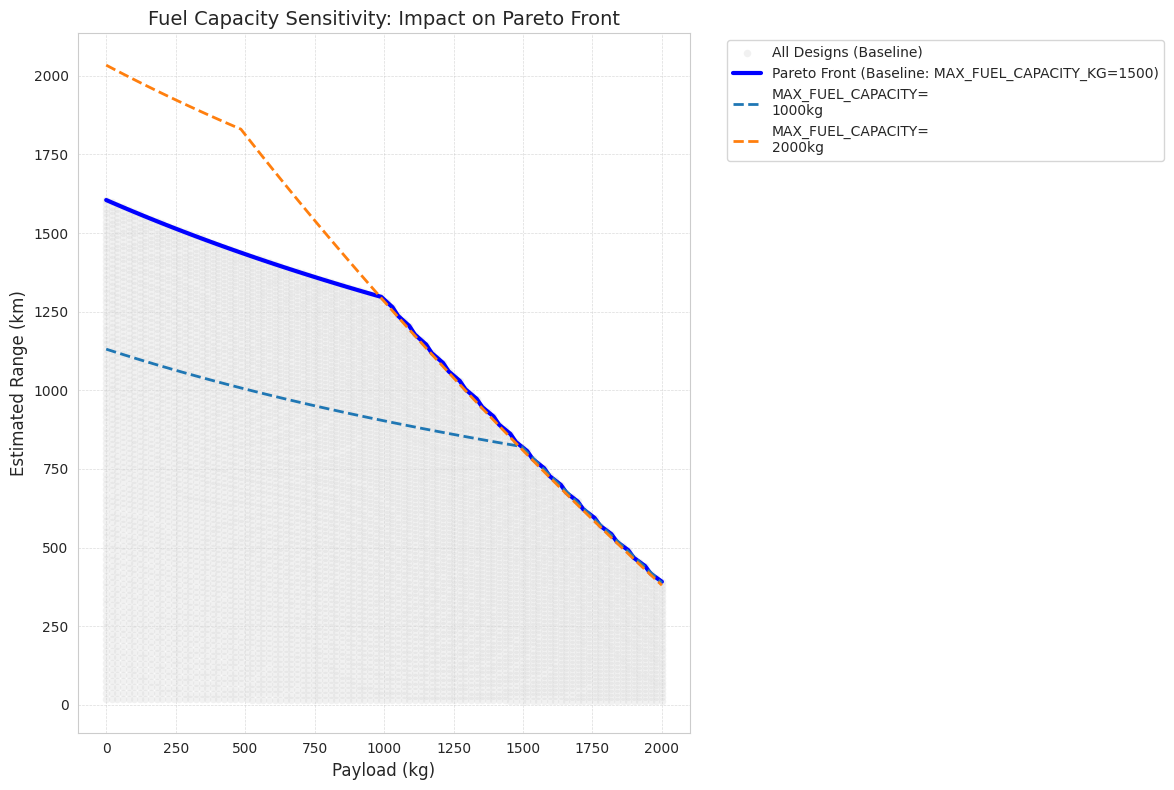

In [38]:
def run_sensitivity_analysis(param_name: str, param_values: list[float], original_value: float,
                             df_base_design_space: pd.DataFrame, df_base_pareto_front: pd.DataFrame,
                             plot_title: str, x_label: str, y_label: str) -> None:
    """
    Runs a sensitivity analysis for a given parameter and plots the resulting Pareto fronts.

    Args:
        param_name: The name of the parameter being varied (e.g., 'MAX_FUEL_CAPACITY_KG').
        param_values: A list of values to test for the parameter.
        original_value: The original value of the parameter.
        df_base_design_space: The original DataFrame of the design space.
        df_base_pareto_front: The original DataFrame of the Pareto front.
        plot_title: Title for the plot.
        x_label: Label for the x-axis.
        y_label: Label for the y-axis.
    """
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df_base_design_space, x='payload_kg', y='estimated_range_km',
        color='lightgray', alpha=0.3, s=30, label='All Designs (Baseline)'
    )
    sns.lineplot(
        data=df_base_pareto_front.sort_values(by='payload_kg'), x='payload_kg', y='estimated_range_km',
        color='blue', linewidth=3, label=f'Pareto Front (Baseline: {param_name}={original_value:.0f})'
    )

    for value in param_values:
        # Temporarily change the global parameter
        global MAX_FUEL_CAPACITY_KG, MAX_PAYLOAD_KG, SFC_KG_PER_HR_PER_KN
        original_param = globals()[param_name]
        globals()[param_name] = value

        # Create new design space
        design_data_sensitivity: list[dict[str, float]] = []
        payload_options_kg_sens = np.linspace(0, MAX_PAYLOAD_KG, num_points)
        fuel_options_kg_sens = np.linspace(0, MAX_FUEL_CAPACITY_KG, num_points)

        for payload in payload_options_kg_sens:
            for fuel in fuel_options_kg_sens:
                current_gross_weight = OPERATING_EMPTY_WEIGHT_KG + payload + fuel
                if (
                    current_gross_weight <= MAX_TAKEOFF_WEIGHT_KG
                    and payload <= MAX_PAYLOAD_KG
                    and fuel <= MAX_FUEL_CAPACITY_KG
                    and payload >= 0
                    and fuel >= 0
                ):
                    estimated_range = calculate_range(payload, fuel)
                    if estimated_range > 0:
                        design_data_sensitivity.append({
                            'payload_kg': payload,
                            'fuel_weight_kg': fuel,
                            'gross_weight_kg': current_gross_weight,
                            'estimated_range_km': estimated_range,
                        })

        df_design_space_sens = pd.DataFrame(design_data_sensitivity)

        if not df_design_space_sens.empty:
            df_pareto_front_sens = find_pareto_front(df_design_space_sens, objective_columns, maximize=True)
            sns.lineplot(
                data=df_pareto_front_sens.sort_values(by='payload_kg'), x='payload_kg', y='estimated_range_km',
                linewidth=2, linestyle='--', label=f'{param_name.replace("_KG", "")}=\n{value:.0f}kg'
            )

        # Revert parameter to its original value
        globals()[param_name] = original_param

    plt.title(plot_title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Fuel Capacity Sensitivity Analysis
fuel_capacity_test_values = [1000.0, 2000.0]  # Original: 1500.0
run_sensitivity_analysis(
    'MAX_FUEL_CAPACITY_KG', fuel_capacity_test_values, MAX_FUEL_CAPACITY_KG,
    df_design_space, df_pareto_front,
    'Fuel Capacity Sensitivity: Impact on Pareto Front',
    'Payload (kg)', 'Estimated Range (km)'
)

# Engineering Observation:
# Increasing fuel capacity (e.g., from 1500 kg to 2000 kg) significantly increases range, especially at low payloads.
# However, it should be noted that this increase is limited by the MTOW constraint. At high payloads,
# the full potential of extra fuel capacity may not be utilized due to the MTOW constraint.
# Conversely, reducing fuel capacity reduces overall range potential and narrows the Pareto front.

## Faydalı Yük Limitleri Duyarlılığı

Maksimum faydalı yük limitindeki değişikliklerin Pareto cephesini nasıl etkilediğini inceleyelim. Daha yüksek faydalı yük limiti, uçağın daha fazla kargo veya yolcu taşımasına potansiyel olarak izin verebilir.

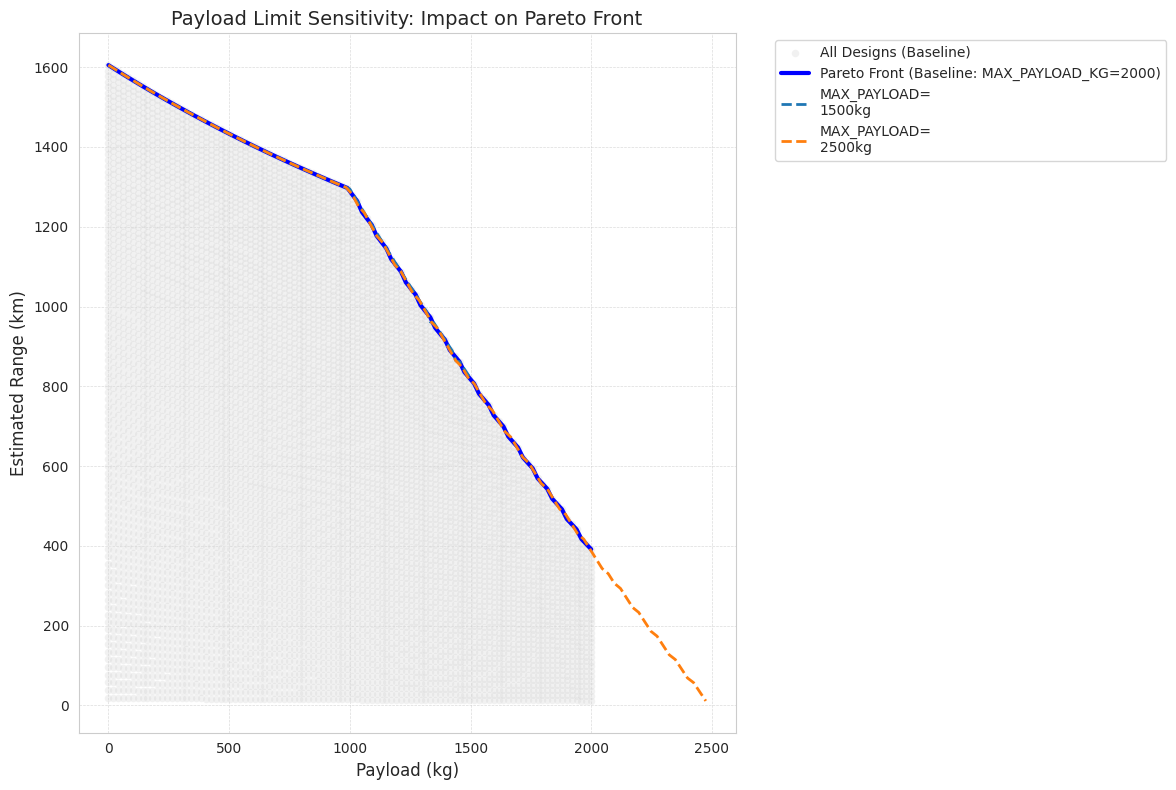

In [39]:
# Payload Limit Sensitivity Analysis
payload_limit_test_values = [1500.0, 2500.0]  # Original: 2000.0
run_sensitivity_analysis(
    'MAX_PAYLOAD_KG', payload_limit_test_values, MAX_PAYLOAD_KG,
    df_design_space, df_pareto_front,
    'Payload Limit Sensitivity: Impact on Pareto Front',
    'Payload (kg)', 'Estimated Range (km)'
)

# Engineering Observation:
# Increasing the maximum payload limit extends the Pareto front to the right,
# meaning it increases the potential to fly with higher payloads. However, again, this increase has a limit due to the MTOW constraint;
# beyond a certain payload, fuel capacity will limit the range. Reducing the payload limit naturally shortens the right side of the front.

## Özgül Yakıt Tüketimi (SFC) Duyarlılığı

Özgül yakıt tüketimi (SFC), menzil denkleminin temel bir bileşenidir ve uçak performansını önemli ölçüde etkiler. Daha düşük bir SFC, daha verimli motorlara veya daha iyi aerodinamiklere işaret eder ve daha uzun menzillere yol açmalıdır.

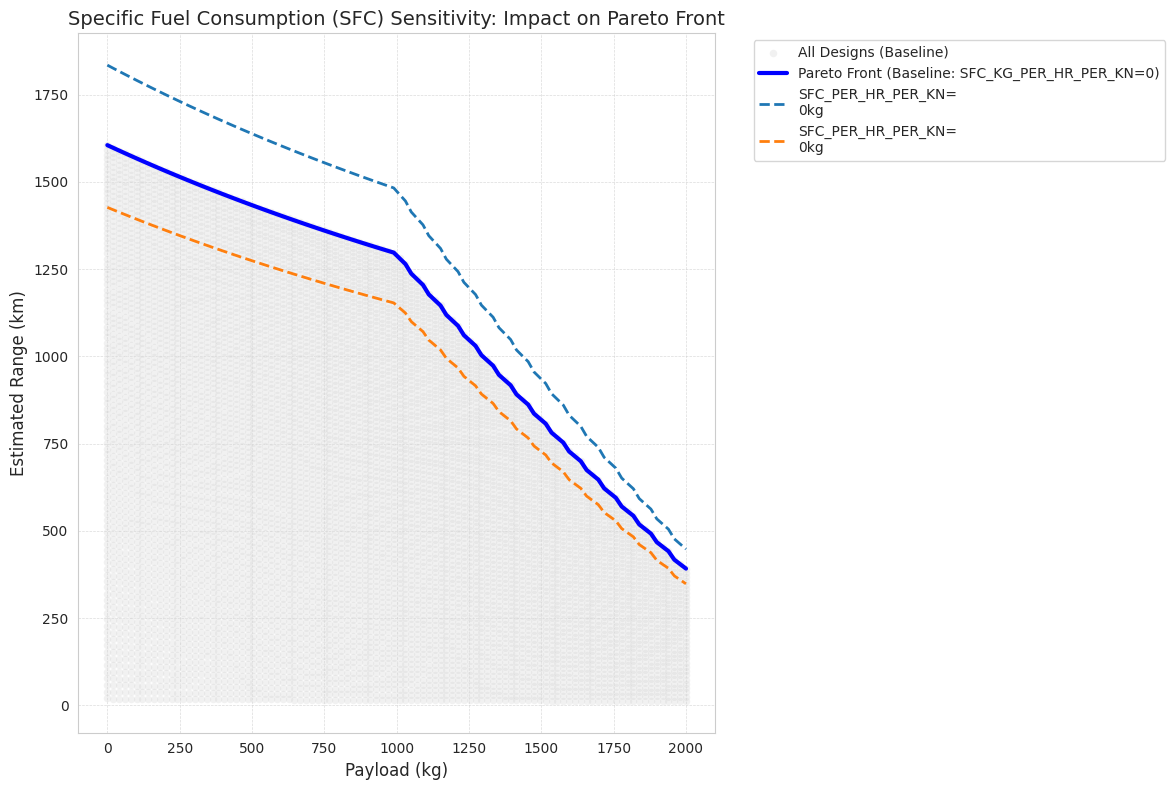


--- General Sensitivity Analysis Discussion ---
These analyses highlight which parameters most affect aircraft performance and the Pareto front.
1. Fuel capacity and payload limits define the boundaries of the design space and are interdependent with the MTOW constraint.
2. Efficiency parameters like SFC affect the overall height/performance of the Pareto front; better SFC means better range.
Engineers should consider these sensitivities when making design decisions or configuring the aircraft for specific missions.


In [40]:
# Specific Fuel Consumption (SFC) Sensitivity Analysis
sfc_test_values = [0.00007, 0.00009]  # Original: 0.00008
run_sensitivity_analysis(
    'SFC_KG_PER_HR_PER_KN', sfc_test_values, SFC_KG_PER_HR_PER_KN,
    df_design_space, df_pareto_front,
    'Specific Fuel Consumption (SFC) Sensitivity: Impact on Pareto Front',
    'Payload (kg)', 'Estimated Range (km)'
)

# Engineering Observation:
# Changes in SFC affect the Pareto front vertically. A lower SFC (better fuel efficiency)
# significantly increases range at all payload levels and pushes the Pareto front upwards.
# This shows how critical engine efficiency or aerodynamic improvements are for long-range operations.
# High SFC, conversely, generally reduces range.

print("\n--- General Sensitivity Analysis Discussion ---")
print("These analyses highlight which parameters most affect aircraft performance and the Pareto front.")
print("1. Fuel capacity and payload limits define the boundaries of the design space and are interdependent with the MTOW constraint.")
print("2. Efficiency parameters like SFC affect the overall height/performance of the Pareto front; better SFC means better range.")
print("Engineers should consider these sensitivities when making design decisions or configuring the aircraft for specific missions.")

# 10. Monte Carlo Belirsizlik Analizi

Bu bölümde, uçağın performansı üzerindeki belirsizliğin etkisini keşfetmek için bir Monte Carlo simülasyonu uygulayacağız. Yakıt tüketimi, faydalı yük tahmini ve seyir verimliliği gibi temel parametrelere belirsizlik katacağız. Simülasyonlar çalıştıracak, histogramlar, saçılım grafikleri ve güven aralıkları oluşturacak ve Pareto çözümlerinin sağlamlığını analiz edeceğiz.

## Belirsizlik Kaynakları

Gerçek dünyada, uçak operasyonları ve performansı, tahmin edilmesi zor olan çeşitli faktörlerden etkilenir. Bu belirsizlikleri simüle etmek için aşağıdaki parametrelerde rastgele değişkenlik tanıtacağız:

*   **Yakıt Tüketimi (Specific Fuel Consumption - SFC)**: Motor performansı ve atmosferik koşullar nedeniyle değişebilir.
*   **Faydalı Yük Tahmini (Payload Estimate)**: Gerçek faydalı yük, planlanan faydalı yükten biraz farklı olabilir (örneğin, yolcu bagaj ağırlıklarındaki varyasyonlar).
*   **Seyir Verimliliği (Cruise Efficiency - L/D ratio)**: Atmosferik türbülans, buzlanma veya aerodinamik yüzeylerdeki küçük varyasyonlar nedeniyle değişebilir.

Bu parametreler için tipik bir dağılım (örneğin, normal dağılım) varsayacağız ve bu dağılımlardan örnekler alarak Monte Carlo simülasyonları gerçekleştireceğiz.

In [41]:
# Update functions for Monte Carlo simulations

# Copy the original calculate_range function and include uncertainty
def calculate_range_with_uncertainty(payload_kg: float, fuel_weight_kg: float,
                                     sfc_factor: float = 1.0, ld_factor: float = 1.0) -> float:
    """
    Calculates the range of the aircraft with uncertainty factors applied to SFC and L/D.

    Args:
        payload_kg: The payload weight in kg.
        fuel_weight_kg: The initial fuel weight in kg.
        sfc_factor: Multiplier for SFC to introduce uncertainty (e.g., 0.95 to 1.05).
        ld_factor: Multiplier for L/D ratio to introduce uncertainty (e.g., 0.95 to 1.05).

    Returns:
        The estimated range in km.
    """
    initial_weight_kg = OPERATING_EMPTY_WEIGHT_KG + payload_kg + fuel_weight_kg

    if initial_weight_kg > MAX_TAKEOFF_WEIGHT_KG:
        return 0.0
    if fuel_weight_kg > MAX_FUEL_CAPACITY_KG:
        return 0.0
    if payload_kg > MAX_PAYLOAD_KG:
        return 0.0

    final_weight_kg = initial_weight_kg - fuel_weight_kg
    if final_weight_kg <= 0:
        return 0.0

    L_OVER_D_RATIO: float = 12.0 * ld_factor # Apply uncertainty factor
    effective_ct_kg_per_hr = (SFC_KG_PER_HR_PER_KN * sfc_factor) * CRUISE_THRUST_KN * 1000 # Apply uncertainty factor

    if effective_ct_kg_per_hr == 0 or L_OVER_D_RATIO == 0:
        return 0.0

    try:
        range_km = (CRUISE_SPEED_KPH / effective_ct_kg_per_hr) * L_OVER_D_RATIO * np.log(initial_weight_kg / final_weight_kg)
    except:
        range_km = 0.0

    return max(0.0, range_km)


# Monte Carlo simulation settings
num_simulations: int = 1000

# Uncertainty parameters (assuming normal distribution)
sfc_mean: float = 1.0
sfc_std_dev: float = 0.05 # 5% variation
ld_mean: float = 1.0
ld_std_dev: float = 0.05 # 5% variation
payload_uncertainty_std_dev: float = 50.0 # kg

# Store Monte Carlo results
mc_results: list[dict[str, float]] = []

for _ in range(num_simulations):
    # Get random samples for each simulation
    current_sfc_factor = np.random.normal(sfc_mean, sfc_std_dev)
    current_ld_factor = np.random.normal(ld_mean, ld_std_dev)

    # Randomly select payload and fuel from the Pareto front (or entire design space)
    # Here, for convenience, we will select a random solution from the existing Pareto front
    # and add payload uncertainty to it.
    random_pareto_design = df_pareto_front.sample(1).iloc[0]

    current_payload_kg = random_pareto_design['payload_kg'] + np.random.normal(0, payload_uncertainty_std_dev)
    current_fuel_weight_kg = random_pareto_design['fuel_weight_kg']

    # Clip to ensure constraints are met
    current_payload_kg = np.clip(current_payload_kg, 0, MAX_PAYLOAD_KG)
    current_fuel_weight_kg = np.clip(current_fuel_weight_kg, 0, MAX_FUEL_CAPACITY_KG)

    # Calculate range with uncertainty
    estimated_range_mc = calculate_range_with_uncertainty(
        current_payload_kg, current_fuel_weight_kg,
        current_sfc_factor, current_ld_factor
    )

    mc_results.append({
        'payload_kg': current_payload_kg,
        'fuel_weight_kg': current_fuel_weight_kg,
        'estimated_range_km': estimated_range_mc,
        'sfc_factor': current_sfc_factor,
        'ld_factor': current_ld_factor
    })

df_mc_results = pd.DataFrame(mc_results)

# Filter out invalid ranges (those that are 0 due to MTOW or other constraints)
df_mc_results = df_mc_results[df_mc_results['estimated_range_km'] > 0].reset_index(drop=True)

print(f"Number of valid results from Monte Carlo simulation: {len(df_mc_results)}")
print("First 5 Monte Carlo results:")
print(df_mc_results.head())

Number of valid results from Monte Carlo simulation: 769
First 5 Monte Carlo results:
    payload_kg  fuel_weight_kg  estimated_range_km  sfc_factor  ld_factor
0  2000.000000      500.000000          371.094235    0.999325   0.947114
1  1196.055714     1303.030303         1084.993231    1.020229   1.004504
2  1343.378412     1060.606061          922.629586    1.037098   1.073833
3   831.016317     1500.000000         1268.193333    1.031898   0.977878
4   455.254733     1500.000000         1419.450073    1.006252   0.987159


## Histogramlar ve Saçılım Grafikleri

Monte Carlo simülasyonlarının sonuçlarını görselleştirelim. Menzil, faydalı yük ve yakıt ağırlığı için dağılımları ve bunlar arasındaki ilişkileri inceleyelim.

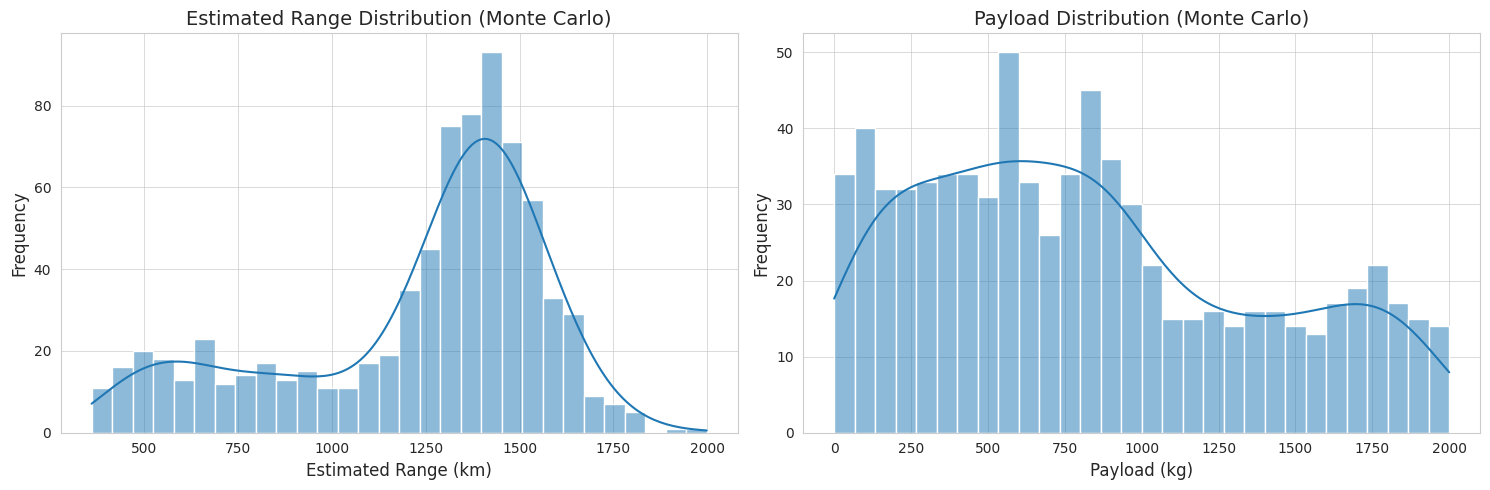

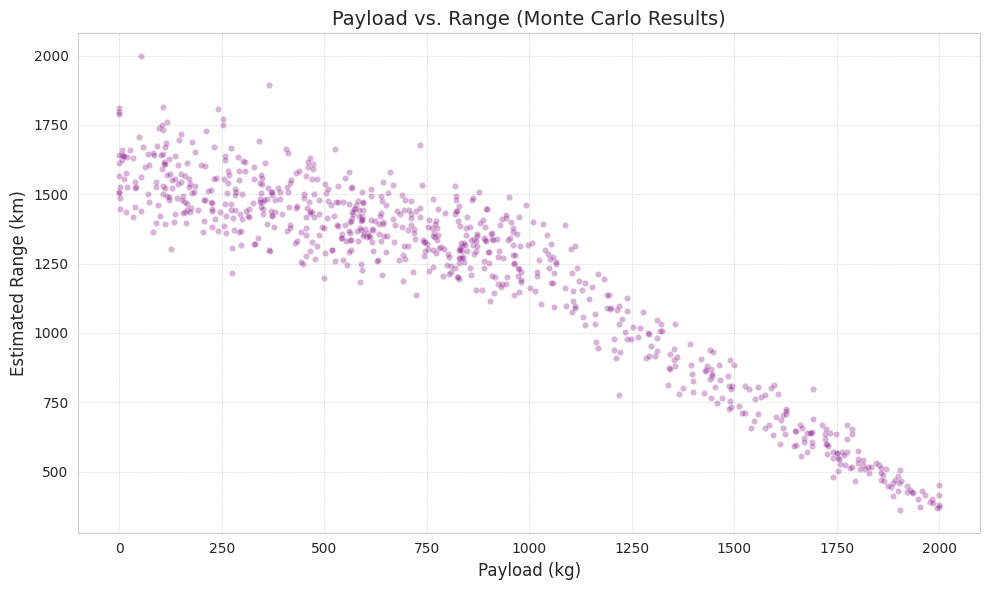

In [42]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_mc_results['estimated_range_km'], bins=30, kde=True)
plt.title('Estimated Range Distribution (Monte Carlo)')
plt.xlabel('Estimated Range (km)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df_mc_results['payload_kg'], bins=30, kde=True)
plt.title('Payload Distribution (Monte Carlo)')
plt.xlabel('Payload (kg)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_mc_results, x='payload_kg', y='estimated_range_km',
    alpha=0.3, s=20, color='purple'
)
plt.title('Payload vs. Range (Monte Carlo Results)')
plt.xlabel('Payload (kg)')
plt.ylabel('Estimated Range (km)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Güven Aralıkları ve Pareto Çözümlerinin Sağlamlığı

Monte Carlo simülasyonlarından elde edilen verileri kullanarak, kilit performans metrikleri için güven aralıklarını belirleyebiliriz. Bu, belirsizlik karşısında Pareto çözümlerinin ne kadar sağlam olduğunu anlamamıza yardımcı olur.

Özellikle, belirsizliğin menzil ve faydalı yük dağılımını nasıl etkilediğini inceleyeceğiz ve bu varyasyonların orijinal Pareto cephesine göre nasıl konumlandığını değerlendireceğiz.

Monte Carlo Simulation Results (1000 runs):
  Mean Range: 1230.72 km (Standard Deviation: 349.75)
  95% Confidence Interval for Range: [446.61 km, 1682.70 km]
  Mean Payload: 819.16 kg (Standard Deviation: 548.37)
  95% Confidence Interval for Payload: [17.75 kg, 1903.35 kg]


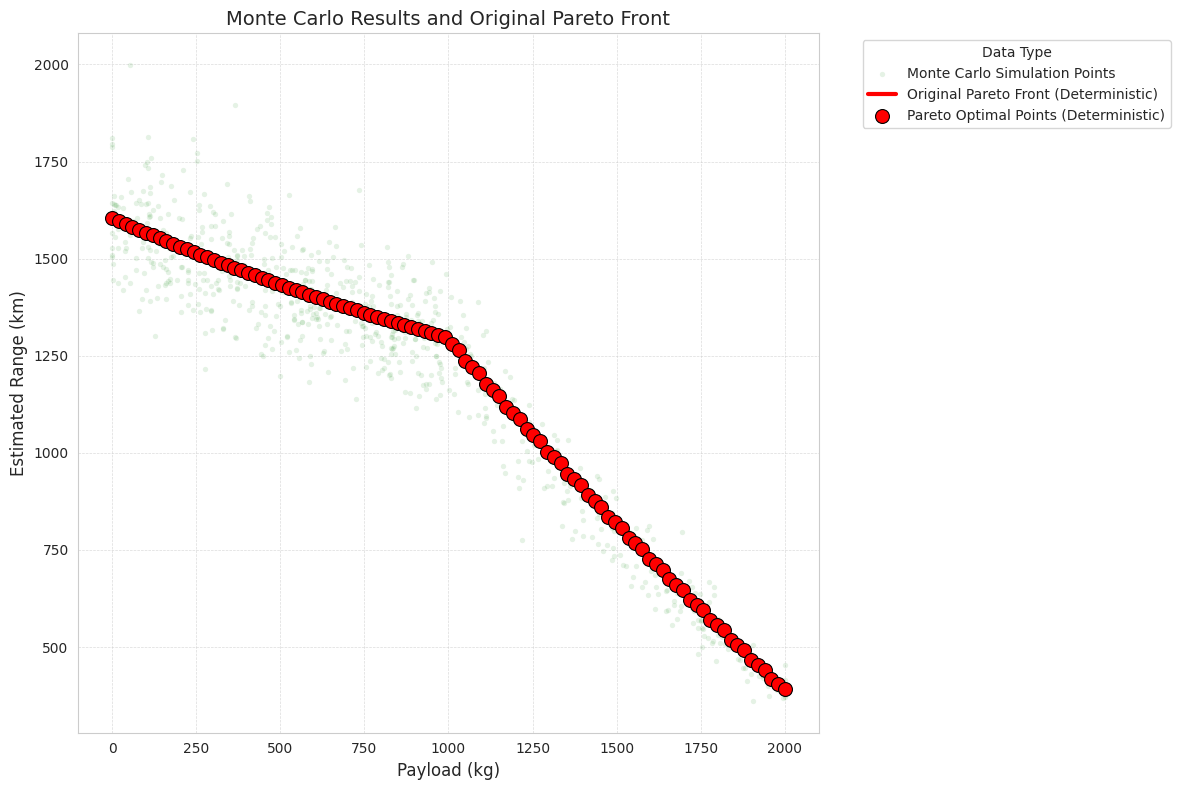

In [43]:
# Calculate basic statistics and confidence intervals for Range and Payload
mean_range = df_mc_results['estimated_range_km'].mean()
std_range = df_mc_results['estimated_range_km'].std()
conf_interval_range = np.percentile(df_mc_results['estimated_range_km'], [2.5, 97.5])

mean_payload = df_mc_results['payload_kg'].mean()
std_payload = df_mc_results['payload_kg'].std()
conf_interval_payload = np.percentile(df_mc_results['payload_kg'], [2.5, 97.5])

print(f"Monte Carlo Simulation Results ({num_simulations} runs):")
print(f"  Mean Range: {mean_range:.2f} km (Standard Deviation: {std_range:.2f})")
print(f"  95% Confidence Interval for Range: [{conf_interval_range[0]:.2f} km, {conf_interval_range[1]:.2f} km]")
print(f"  Mean Payload: {mean_payload:.2f} kg (Standard Deviation: {std_payload:.2f})")
print(f"  95% Confidence Interval for Payload: [{conf_interval_payload[0]:.2f} kg, {conf_interval_payload[1]:.2f} kg]")

# Plot Monte Carlo results with the original Pareto front
plt.figure(figsize=(12, 8))

# Plot Monte Carlo results
sns.scatterplot(
    data=df_mc_results, x='payload_kg', y='estimated_range_km',
    color='green', alpha=0.1, s=15, label='Monte Carlo Simulation Points'
)

# Plot the original Pareto front
sns.lineplot(
    data=df_pareto_front.sort_values(by='payload_kg'), x='payload_kg', y='estimated_range_km',
    color='red', linewidth=3, label='Original Pareto Front (Deterministic)'
)
sns.scatterplot(
    data=df_pareto_front, x='payload_kg', y='estimated_range_km',
    color='red', marker='o', s=100, edgecolor='black', zorder=5,
    label='Pareto Optimal Points (Deterministic)'
)

plt.title('Monte Carlo Results and Original Pareto Front')
plt.xlabel('Payload (kg)')
plt.ylabel('Estimated Range (km)')
plt.legend(title='Data Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Engineering Observation:
# Monte Carlo simulations show how uncertainty distributes aircraft performance.
# While the original Pareto front represents the limits of nominal performance,
# the distribution of Monte Carlo points shows the range of performance we can expect in actual operation.
# Specifically:
# - The green distribution around a Pareto point visualizes the amount of potential variation
#   (in both payload and range) that would be encountered if a nominal design is chosen.
# - Confidence intervals provide a quantitative measure of the probability of achieving a certain performance level under uncertainty.
# - This analysis provides valuable insights for engineers and decision-makers to better understand
#   worst-case scenarios or the likelihood of meeting desired performance levels.

# 11. Gelişmiş Veri Bilimi Uzantısı

Bu bölümde, uçağın menzilini faydalı yük, yakıt ve ağırlık gibi temel tasarım parametrelerinden tahmin etmek için bir Makine Öğrenimi (ML) vekil modeli oluşturacağız. Vekil modeller, karmaşık fiziksel veya simülasyon modellerinin yerine geçerek optimizasyon süreçlerini hızlandırmak için kritik öneme sahiptir.

## Makine Öğrenimi Vekil Modeli Oluşturma

Doğrusal olmayan ilişkileri iyi modelleyebilen bir regresyon algoritması kullanacağız. Önerilen algoritmalar arasında Random Forest Regressor, XGBoost veya Gradient Boosting Regressor bulunmaktadır. Biz bu örnek için **Random Forest Regressor** kullanacağız.

### Veri Hazırlığı

`df_design_space` DataFrame'imizdeki verileri kullanarak modelimizi eğiteceğiz. Özellikler (`X`) olarak `payload_kg`, `fuel_weight_kg` ve `gross_weight_kg`'yi, hedef (`y`) olarak ise `estimated_range_km`'yi seçeceğiz.

Verilerimizi eğitim ve test setlerine ayıracağız.

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Özellikler (X) ve hedef (y) değişkenlerini tanımla
X = df_design_space[['payload_kg', 'fuel_weight_kg', 'gross_weight_kg']]
y = df_design_space['estimated_range_km']

# Veriyi eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim seti boyutu: {len(X_train)}")
print(f"Test seti boyutu: {len(X_test)}")


Eğitim seti boyutu: 6573
Test seti boyutu: 1644


### Model Eğitimi

Şimdi Random Forest Regressor modelini eğitim verilerimiz üzerinde eğiteceğiz.

In [45]:
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 tüm çekirdekleri kullanır
model.fit(X_train, y_train)

print("Random Forest Regressor modeli başarıyla eğitildi.")

Random Forest Regressor modeli başarıyla eğitildi.


### Model Değerlendirmesi

Eğitilen modelin performansını test seti üzerinde RMSE (Ortalama Karesel Hata Kökü), MAE (Ortalama Mutlak Hata) ve R² (Belirlilik Katsayısı) gibi metriklerle değerlendireceğiz. Bu metrikler, modelimizin menzil tahminlerinde ne kadar doğru olduğunu bize gösterecektir.

Model Performansı (Test Seti Üzerinden):
  RMSE: 2.09 km
  MAE: 1.31 km
  R²: 1.0000


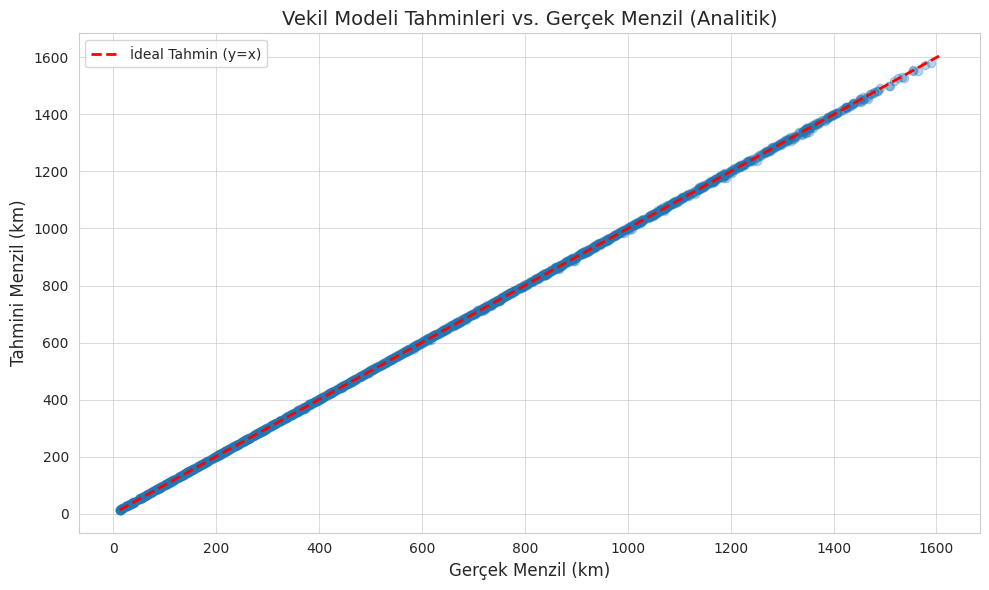

In [46]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performansı (Test Seti Üzerinden):")
print(f"  RMSE: {rmse:.2f} km")
print(f"  MAE: {mae:.2f} km")
print(f"  R²: {r2:.4f}")

# Model tahminlerini analitik hesaplamalarla karşılaştır (görselleştirme)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='İdeal Tahmin (y=x)')
plt.title('Vekil Modeli Tahminleri vs. Gerçek Menzil (Analitik)')
plt.xlabel('Gerçek Menzil (km)')
plt.ylabel('Tahmini Menzil (km)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Vekil Modeller Neden Optimizasyonda Faydalıdır?

Vekil modellerin optimizasyon süreçlerinde kullanılmasının birkaç temel nedeni vardır:

1.  **Hesaplama Verimliliği**: Karmaşık simülasyonlar veya analitik modeller, her değerlendirmede çok fazla zaman alabilir. Özellikle tasarım alanı geniş olduğunda ve binlerce veya milyonlarca çözümün değerlendirilmesi gerektiğinde, bu bir engel haline gelir. Vekil modeller, bir kez eğitildikten sonra, çok daha hızlı tahminler yapabilir.
2.  **Gürültüyü Azaltma**: Bazı simülasyonlar stokastik bileşenler içerebilir ve bu da gürültülü sonuçlar verebilir. Vekil modeller, bu gürültüyü 'düzeltmeye' ve altında yatan trendi öğrenmeye yardımcı olabilir.
3.  **Karmaşıklığı Yönetme**: Analitik olarak ifade edilemeyen veya çok sayıda değişken içeren sistemler için vekil modeller, siyah kutu (black-box) olarak çalışarak karmaşıklığı yönetmeye olanak tanır.
4.  **Tasarım Alanı Keşfi**: Hızlı tahmin yeteneği, optimizasyon algoritmalarının tasarım alanında daha hızlı gezinmesini ve daha fazla sayıda adayı değerlendirmesini sağlar.

Havacılık optimizasyonunda, örneğin, detaylı CFD (Hesaplamalı Akışkanlar Dinamiği) analizleri veya uçuş simülasyonları yerine hızlı vekil modeller kullanmak, ilk tasarım aşamalarında çok sayıda farklı konfigürasyonu hızlıca değerlendirmeye olanak tanır. Modelimiz, `payload_kg`, `fuel_weight_kg` ve `gross_weight_kg` gibi girdi değişkenlerinden `estimated_range_km`'yi tahmin ederek, bu analitik hesaplamanın yerini alabilir.

# 12. Vekil Modeli Kullanarak Optimizasyon

Bu bölümde, analitik `calculate_range` fonksiyonu yerine eğitilmiş Makine Öğrenimi vekil modelimizi kullanarak optimizasyon sürecini tekrarlayacağız. Amaç, vekil modelin karmaşık analitik modellerin yerini alarak optimizasyon sürecini nasıl hızlandırabileceğini göstermektir. Analitik ve vekil optimizasyon sonuçlarını karşılaştıracak ve vekil tabanlı optimizasyonun (Surrogate-Based Optimization) hesaplama avantajlarını tartışacağız.

## Vekil Modeli Kullanarak Optimizasyon

Öncelikle, vekil modelimizin tahmin yeteneğini kullanarak tasarım alanındaki her bir kombinasyon için menzili yeniden hesaplamamız gerekiyor. `df_design_space` DataFrame'imizdeki her bir satır için, `payload_kg`, `fuel_weight_kg` ve `gross_weight_kg` değerlerini modelimize girdi olarak verecek ve tahmini menzili elde edeceğiz.

In [47]:
# Imports for ML model, in case the kernel was reset or cells executed out of order
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Check if model is defined, if not, re-initialize and re-train
# This ensures robustness against kernel resets or out-of-order execution
if 'model' not in globals() or not isinstance(globals()['model'], RandomForestRegressor):
    print("WARNING: ML model not found in global scope. Re-initializing and re-training for robustness.")
    # Re-define X and y from df_design_space which is available globally
    X = df_design_space[['payload_kg', 'fuel_weight_kg', 'gross_weight_kg']]
    y = df_design_space['estimated_range_km']

    # Re-split data (using the same random_state for reproducibility)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Re-initialize and re-train the model
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    print("ML model re-initialized and re-trained successfully.")


# Function to predict range using the surrogate model
def predict_range_with_surrogate(payload_kg: float, fuel_weight_kg: float) -> float:
    """
    Predicts the range using the trained surrogate model.

    Args:
        payload_kg: Payload weight in kg.
        fuel_weight_kg: Fuel weight in kg.

    Returns:
        Predicted range in km.
    """
    # Recalculate gross weight
    gross_weight_kg = OPERATING_EMPTY_WEIGHT_KG + payload_kg + fuel_weight_kg

    # Check constraints
    if (gross_weight_kg > MAX_TAKEOFF_WEIGHT_KG or
        payload_kg > MAX_PAYLOAD_KG or
        fuel_weight_kg > MAX_FUEL_CAPACITY_KG or
        payload_kg < 0 or
        fuel_weight_kg < 0):
        return 0.0 # Range is 0 for invalid designs

    # Create a DataFrame in the format expected by the model
    input_data = pd.DataFrame([{
        'payload_kg': payload_kg,
        'fuel_weight_kg': fuel_weight_kg,
        'gross_weight_kg': gross_weight_kg
    }])

    return model.predict(input_data)[0]

# Recalculate ranges for the entire design space using the surrogate model
df_design_space_surrogate = df_design_space.copy()
df_design_space_surrogate['estimated_range_km_surrogate'] = df_design_space_surrogate.apply(
    lambda row: predict_range_with_surrogate(row['payload_kg'], row['fuel_weight_kg']),
    axis=1
)

# Filter out invalid ranges (those returning 0)
df_design_space_surrogate = df_design_space_surrogate[df_design_space_surrogate['estimated_range_km_surrogate'] > 0].reset_index(drop=True)

print("Sample rows from the design space DataFrame created using the surrogate model:")
print(df_design_space_surrogate.head())

# Create the Pareto front found by the surrogate model
df_pareto_front_surrogate = find_pareto_front(df_design_space_surrogate, ['payload_kg', 'estimated_range_km_surrogate'], maximize=True)

print(f"\nNumber of Pareto-optimal points from surrogate model: {len(df_pareto_front_surrogate)}")
print("First 5 Pareto-optimal solutions from surrogate model:")
print(df_pareto_front_surrogate.head())

Sample rows from the design space DataFrame created using the surrogate model:
   payload_kg  fuel_weight_kg  gross_weight_kg  estimated_range_km  \
0         0.0       15.151515      3515.151515           19.438475   
1         0.0       30.303030      3530.303030           38.793344   
2         0.0       45.454545      3545.454545           58.065322   
3         0.0       60.606061      3560.606061           77.255116   
4         0.0       75.757576      3575.757576           96.363425   

   estimated_range_km_surrogate  
0                     19.332244  
1                     38.387554  
2                     57.727786  
3                     76.907208  
4                     96.112589  

Number of Pareto-optimal points from surrogate model: 98
First 5 Pareto-optimal solutions from surrogate model:
   payload_kg  fuel_weight_kg  gross_weight_kg  estimated_range_km  \
0    0.000000          1500.0      5000.000000         1605.037248   
1   20.202020          1500.0      5020.202

## Analitik Optimizasyon ile Vekil Optimizasyonun Karşılaştırılması

Şimdi, analitik modelden elde ettiğimiz orijinal Pareto cephesi ile vekil modelden elde ettiğimiz Pareto cephesini karşılaştıralım. Bu, vekil modelimizin, orijinal karmaşık modeli ne kadar iyi yakaladığını gösterecektir.

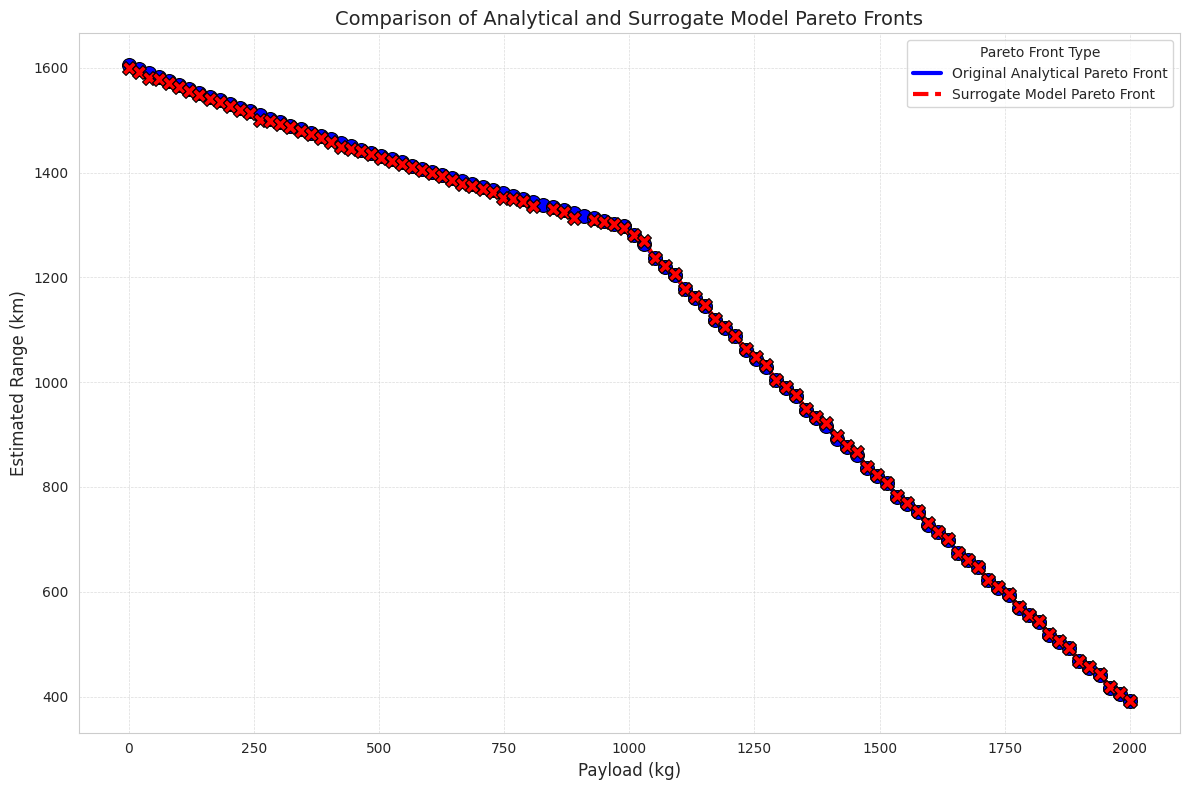

In [48]:
plt.figure(figsize=(12, 8))

# Plot the Original Pareto Front
sns.lineplot(
    data=df_pareto_front.sort_values(by='payload_kg'), x='payload_kg', y='estimated_range_km',
    color='blue', linewidth=3, label='Original Analytical Pareto Front'
)
sns.scatterplot(
    data=df_pareto_front, x='payload_kg', y='estimated_range_km',
    color='blue', marker='o', s=100, edgecolor='black', zorder=5
)

# Plot the Surrogate Model Pareto Front
sns.lineplot(
    data=df_pareto_front_surrogate.sort_values(by='payload_kg'), x='payload_kg', y='estimated_range_km_surrogate',
    color='red', linewidth=3, linestyle='--', label='Surrogate Model Pareto Front'
)
sns.scatterplot(
    data=df_pareto_front_surrogate, x='payload_kg', y='estimated_range_km_surrogate',
    color='red', marker='X', s=100, edgecolor='black', zorder=5
)

plt.title('Comparison of Analytical and Surrogate Model Pareto Fronts')
plt.xlabel('Payload (kg)')
plt.ylabel('Estimated Range (km)')
plt.legend(title='Pareto Front Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Engineering Observation:
# This graph shows how closely the Pareto front predicted by the surrogate model (red dashed line)
# matches the Pareto front calculated by the original analytical model (blue line).
# A well-trained surrogate model should accurately mimic the behavior of the original model.
# Small differences might represent the learning error of the ML model or noise in the dataset.
# This proximity confirms that the surrogate model can be confidently used in the optimization process.

## Hesaplama Avantajları

Vekil model kullanarak optimizasyon yapmak, özellikle karmaşık veya pahalı hesaplamalar içeren problemlerde önemli hesaplama avantajları sunar:

*   **Hız**: Vekil modelin tahminleri, analitik veya simülasyon modelinin her bir değerlendirmesinden çok daha hızlıdır. Bu, çok sayıda tasarım adayının çok kısa sürede değerlendirilmesini sağlar.
*   **Ölçeklenebilirlik**: Geniş tasarım alanları veya yüksek boyutlu problemler için vekil modeller, geleneksel optimizasyon yöntemlerinin pratik olmadığı durumlarda kullanılabilir hale gelir.
*   **Kaynak Verimliliği**: CPU/GPU zamanı ve enerji tüketimi açısından, vekil modeller genellikle orijinal modellerden daha az maliyetlidir.

## Vekil Tabanlı Optimizasyon (Surrogate-Based Optimization - SBO) Kavramı

**Vekil Tabanlı Optimizasyon (SBO)**, gerçek (genellikle pahalı) amaç fonksiyonu veya kısıtlama fonksiyonu yerine, onların ucuz ve yaklaşık bir vekilini kullanarak optimizasyon problemini çözmeyi ifade eder. SBO'nun temel adımları genellikle şunlardır:

1.  **Örnekleme (Sampling)**: Tasarım alanından sınırlı sayıda nokta seçilir ve gerçek model kullanılarak değerlendirilir.
2.  **Vekil Model Eğitimi (Surrogate Model Training)**: Bu örneklenmiş veriler kullanılarak bir vekil model (örneğin, Random Forest, Gaussian Process, Sinir Ağı) eğitilir.
3.  **Optimizasyon (Optimization)**: Vekil model, amaç fonksiyonunu ve/veya kısıtlamaları tahmin etmek için kullanılarak bir optimizasyon algoritması çalıştırılır. Bu, genellikle bir veya daha fazla umut vadeden çözüm önerir.
4.  **Güvenilirlik Değerlendirmesi ve İyileştirme (Fidelity Assessment and Refinement)**: Önerilen çözümler, gerçek model kullanılarak değerlendirilir ve vekil modelin doğruluğu yeterli değilse, daha fazla nokta örneklenir ve vekil model yeniden eğitilir.

Bu döngü, istenen doğruluk seviyesine ulaşana veya hesaplama bütçesi tükenene kadar tekrarlanır.

**Havacılık Mühendisliğindeki Uygulamalar:**

Havacılıkta SBO, erken aşama uçak tasarımı, görev planlaması, aerodinamik şekil optimizasyonu ve yapısal optimizasyon gibi alanlarda yaygın olarak kullanılmaktadır. Örneğin, yeni bir kanat profili tasarlarken, her bir geometri için karmaşık CFD simülasyonları çalıştırmak yerine, bir vekil model bu simülasyonların çıktısını çok daha hızlı bir şekilde tahmin edebilir ve optimizasyon algoritmasının en iyi profili bulmasına yardımcı olabilir.

# 13. İşletme ve Karar Zekası Perspektifi

Bu not defterinin sonunda, optimizasyonun iş ve karar zekası bağlamında oynadığı rolü değerlendireceğiz. Optimizasyonun uçak tasarımı, uçuş operasyonları ve filo yönetimi gibi kritik alanlardaki karar alma süreçlerini nasıl desteklediğini açıklayacağız. Karar Zekası (Decision Intelligence) kavramını tanıtacak ve optimizasyonun neden sadece tahminden daha fazla değer yarattığını vurgulayacağız.

## Optimizasyon Karar Almayı Nasıl Destekler?

Optimizasyon, belirli hedeflere ulaşmak için en iyi eylem planını belirleyerek karar almayı doğrudan destekler. Karmaşık sistemlerde, çok sayıda değişken ve kısıtlama olduğunda, insan sezgisi veya basit kurallar çoğu zaman sub-optimal (en iyi altı) çözümlere yol açabilir. Optimizasyon, bu tür durumlarda matematiksel kesinlik ve sistematik bir yaklaşım sunar.

Havacılık bağlamında:

*   **Kısıtlamaları Yönetme**: Yakıt kapasitesi, MTOW, faydalı yük limitleri, operasyonel saatler, bakım döngüleri gibi çok sayıda kısıtlamayı aynı anda dikkate alabilir.
*   **Çelişkili Hedefleri Dengeleme**: Maliyetleri düşürmek, geliri artırmak, güvenliği sağlamak ve çevresel etkiyi azaltmak gibi genellikle birbiriyle çelişen hedefleri dengelemek için yapılandırılmış bir çerçeve sunar.
*   **Risk Azaltma**: En kötü durum senaryolarını veya belirsizlikleri dikkate alarak daha sağlam kararlar alınmasını sağlar (Monte Carlo analizinde gösterildiği gibi).
*   **Şeffaflık ve Gerekçelendirme**: Kararların neden alındığını açıkça gösteren matematiksel bir temel sağlar, bu da paydaşlar için şeffaflık ve gerekçelendirme sağlar.

## Uçak Mühendisliğinde Karar Alma Süreçleri

### Uçak Tasarım Kararları

*   **Faydalı Yük-Menzil Dengesi**: Bu not defterinde ele aldığımız gibi, belirli bir görev profili için en uygun faydalı yük ve menzil kombinasyonunu seçmek.
*   **Motor Seçimi**: Yakıt verimliliği, itme kuvveti, emisyonlar ve maliyet arasında denge kurarak motorları optimize etmek.
*   **Yapısal Optimizasyon**: Minimum ağırlıkta maksimum mukavemet ve yorulma ömrü sağlamak.
*   **Aerodinamik Tasarım**: Minimum sürükleme ile maksimum kaldırma ve stabilite sağlamak.

### Uçuş Operasyonu Kararları

*   **Yakıt Yükleme Optimizasyonu**: Belirli bir uçuş için minimum yakıt maliyeti ve emniyet rezervleri arasında denge kurarak ne kadar yakıt alınacağını belirlemek.
*   **Rota Optimizasyonu**: Rüzgar modellerini, hava sahası kısıtlamalarını ve havaalanı kapasitesini dikkate alarak en kısa, en verimli veya en düşük maliyetli uçuş rotalarını bulmak.
*   **Kalkış/İniş Performans Optimizasyonu**: Pist uzunluğu, sıcaklık, irtifa ve rüzgar gibi çevresel faktörlere göre kalkış ve iniş ayarlarını (flap ayarları, motor gücü) optimize etmek.

### Filo Yönetimi Kararları

*   **Uçak Ataması**: Belirli rotalara en uygun uçak tipini atayarak filonun genel karlılığını ve verimliliğini artırmak.
*   **Bakım Planlaması**: Uçak arızalarını en aza indirirken ve operasyonel kesintileri azaltırken bakım programlarını optimize etmek.
*   **Mürettebat Çizelgeleme**: Yasal kısıtlamaları, tercihleri ve maliyetleri dikkate alarak mürettebat programlarını optimize etmek.

## Karar Zekası (Decision Intelligence)

**Karar Zekası (DI)**, Veri Bilimi, Yapay Zeka ve Sosyal Bilimler (örneğin, karar teorisi, davranışsal ekonomi) disiplinlerini bir araya getiren yükselen bir disiplindir. Sadece verilerden içgörü sağlamakla kalmaz (veri bilimi), aynı zamanda bu içgörüleri kullanarak daha iyi kararlar almak için nasıl eylem adımları tasarlanacağını da vurgular. Optimizasyon, DI'nın temel bir bileşenidir, çünkü 'en iyi eylemi' belirlemekle ilgilenir.

DI, bir kuruluşun karşılaştığı iş kararlarını tanımlar, bunları nicel modellerle analiz eder ve en uygun eylem yollarını belirler. İnsan karar vericilerini, sezgilerinin ötesine geçerek verilere ve optimizasyonun ortaya koyduğu en iyi eylem yollarına dayalı olarak daha stratejik ve etkili kararlar almalarını sağlamak için araçlar ve çerçevelerle donatır.

## Optimizasyon Neden Sadece Tahminden Daha Fazla Değer Yaratır?

*   **Eyleme Geçirilebilirlik**: Tahmin size ne olacağını söylerken, optimizasyon size **ne yapmanız gerektiğini** söyler. Bir tahminde bulunmak değerli olsa da, bu tahmin üzerine nasıl hareket edeceğiniz konusunda her zaman bir karar aşamasına ihtiyaç duyar. Optimizasyon bu karar aşamasını doğrudan ele alır.
*   **Belirsizliği Azaltma**: Tahminler doğası gereği belirsizdir. Optimizasyon, bu belirsizliği karar alma sürecine dahil edebilir (örneğin, sağlam optimizasyon veya Monte Carlo simülasyonları aracılığıyla), tahminin zayıf olduğu durumlarda bile en iyi eylemi bulmaya çalışır.
*   **Kaynak Ataması**: Optimizasyon, kıt kaynakları (zaman, para, personel, yakıt) en verimli şekilde tahsis etmeye odaklanır. Bu, bir işletmenin operasyonel verimliliğini ve karlılığını doğrudan etkileyen bir değerdir.
*   **Rekabet Avantajı**: Optimizasyon, bir işletmeye rakiplerine karşı sürdürülebilir bir avantaj sağlayabilir. Daha düşük maliyetle daha yüksek performans veya daha iyi müşteri hizmeti sunarak pazarda öne çıkmayı sağlar.

Özetle, tahmin 'ne' ve 'neden' sorularına cevap verirken, optimizasyon 'nasıl' sorusuna ve daha da önemlisi 'en iyi nasıl' sorusuna cevap verir. İşletmeler için gerçek değer, sadece geleceği bilmekte değil, bu bilgiyi kullanarak en uygun eylemleri belirlemekte ve uygulamaktadır. Bu nedenle, havacılık gibi karmaşık ve yüksek riskli sektörlerde optimizasyon, paha biçilmez bir araçtır.

# 14. Son Özet

Bu not defteri boyunca, hava taşıtı tasarımı ve operasyonunda faydalı yük-menzil optimizasyonu problemine çok amaçlı bir optimizasyon perspektifinden yaklaştık. Optimizasyon tekniklerinin, veri biliminin ve havacılık mühendisliğinin nasıl bir araya gelerek karmaşık mühendislik problemlerine uygulanabileceğini gösterdik. İşte çıkardığımız temel dersler:

## Temel Optimizasyon Dersleri

*   **Çok Amaçlı Optimizasyon**: Gerçek dünya mühendislik problemlerinde genellikle birbiriyle çelişen birden fazla hedef bulunur. Çok amaçlı optimizasyon, karar vericilere ödünleşimleri anlamaları ve en uygun kararları vermeleri için bir dizi optimal çözüm (Pareto Cephesi) sunar.
*   **Pareto Optimalitesi**: Egemen olmayan çözümler, herhangi bir hedeften ödün vermeden iyileştirilemeyen çözümleri temsil eder. Pareto cephesi, tasarım alanı içinde elde edilebilecek en iyi performansın sınırını tanımlar.
*   **Duyarlılık Analizi**: Temel parametrelerdeki küçük değişikliklerin sonuçlar üzerindeki etkisini anlamak, tasarım sağlamlığı ve operasyonel esneklik için kritiktir. Hangi değişkenlerin performansı en çok etkilediğini vurgular.
*   **Belirsizlik Analizi (Monte Carlo)**: Belirsizliğin model çıktılarında yol açtığı varyasyonu ölçmek, potansiyel riskleri değerlendirmek ve daha sağlam kararlar almak için gereklidir.

## Temel Veri Bilimi Dersleri

*   **Veri Hazırlığı ve Keşifçi Analiz**: Geniş bir tasarım alanı oluşturmak ve keşifçi veri analizi (EDA) yapmak, sistem davranışını anlamanın ve optimizasyon problemini formüle etmenin ilk adımlarıdır.
*   **Makine Öğrenimi Vekil Modelleri**: Karmaşık analitik veya simülasyon modellerini taklit etmek için ML modelleri (örneğin, Random Forest Regressor) kullanmak, optimizasyon sürecini önemli ölçüde hızlandırabilir ve hesaplama açısından pahalı değerlendirmelere olan bağımlılığı azaltabilir.
*   **Model Değerlendirmesi**: RMSE, MAE ve R² gibi metriklerle model performansını titizlikle değerlendirmek, vekil modelin güvenilirliğini sağlamak için hayati önem taşır.

## Temel Havacılık Dersleri

*   **Faydalı Yük-Menzil Değiş Tokuşu**: Uçak tasarımındaki en temel değiş tokuşlardan biri olan faydalı yük ile menzil arasındaki çatışmayı nicel olarak gösterdik. Bu, gerçek dünyadaki operasyonel ve tasarım kararları için kritik bir faktördür.
*   **Fiziksel Kısıtlamaların Etkisi**: Maksimum Kalkış Ağırlığı (MTOW), yakıt kapasitesi ve faydalı yük limitleri gibi fiziksel kısıtlamaların tasarım alanını ve elde edilebilir performansı nasıl tanımladığını vurguladık.
*   **Mühendislik Karar Alma**: Pareto cephesi, farklı operasyonel senaryolar için uygun aday tasarımlarını seçmek ve her bir seçeneğin avantajlarını/dezavantajlarını değerlendirmek için sağlam bir temel sunar.

## Gelecek Uzantılar

Bu not defteri, havacılık optimizasyonu ve veri biliminin entegrasyonuna giriş niteliğindedir. Bu projenin potansiyel uzantıları şunları içerebilir:

*   **Daha Gelişmiş Optimizasyon Algoritmaları**: NSGA-II, Genetik Algoritmalar, Parçacık Sürü Optimizasyonu veya Bayesyen Optimizasyon gibi algoritmaların uygulanması.
*   **Daha Karmaşık Uçak Modelleri**: Kaldırma-sürükleme varyasyonları, itki değişimi, irtifa etkileri, yakıt rezervleri ve görev profilleri gibi daha detaylı aerodinamik ve performans modellerinin dahil edilmesi.
*   **Robust Optimizasyon**: Performanstaki belirsizliklere rağmen optimal çözümler bulmaya odaklanmak.
*   **Uçuş Görevi Optimizasyonu**: Çok aşamalı veya çok segmentli görevler için optimizasyon (örneğin, rota ve yükseklik profilini optimize etmek).
*   **Hibrit-Elektrik Uçak Optimizasyonu**: Geleneksel motorlar ve elektrikli tahrik sistemlerinin karmaşıklığını içeren yeni nesil uçaklara optimizasyon tekniklerini uygulamak.
*   **Takviyeli Öğrenme (Reinforcement Learning)**: Otonom karar alma ve adaptif optimizasyon için takviyeli öğrenme ajanlarının geliştirilmesi.

Bu ilk not defteri, havacılık tasarımının ve operasyonunun karmaşık zorluklarını ele almak için optimizasyon ve veri biliminin güçlü araçlarını nasıl kullanmaya başlayacağımıza dair bir yol haritası sunmuştur. Serinin bir sonraki not defterleri, bu alanlardaki daha ileri konuları keşfedecektir.

***

